In [85]:
import json
import os
from pathlib import Path
from collections import Counter
import re
import matplotlib.pyplot as plt
import numpy as np

# 设置输出目录路径
output_dir = Path("../agentnetbench/outputs/Qwen3-VL-4B-Thinking/None")

def extract_thinking_content(raw_response):
    """提取<tool_call>之前的思维链内容"""
    # 查找<tool_call>的位置
    tool_call_idx = raw_response.find('<tool_call>')
    
    if tool_call_idx != -1:
        # 如果找到<tool_call>，只返回之前的内容
        return raw_response[:tool_call_idx].strip()
    else:
        # 如果没有<tool_call>，返回全部内容
        return raw_response.strip()

# 读取所有JSON文件并提取raw_response中的思维链部分
all_responses = []
all_full_responses = []  # 保存完整的response用于对比
files_count = 0

print(f"正在读取 {output_dir} 中的文件...")
for json_file in output_dir.glob("*.json"):
    files_count += 1
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        for step in data:
            if 'raw_response' in step:
                full_response = step['raw_response']
                thinking_content = extract_thinking_content(full_response)
                
                all_full_responses.append(full_response)
                all_responses.append(thinking_content)

print(f"总共读取了 {files_count} 个JSON文件")
print(f"提取了 {len(all_responses)} 个回复")

# 统计有多少个回复包含<tool_call>
responses_with_tool_call = sum(1 for r in all_full_responses if '<tool_call>' in r)
print(f"其中 {responses_with_tool_call} 个回复包含 <tool_call> ({responses_with_tool_call/len(all_responses)*100:.1f}%)")

# 计算思维链内容占比
avg_full_length = np.mean([len(r) for r in all_full_responses])
avg_thinking_length = np.mean([len(r) for r in all_responses])
print(f"\n平均完整回复长度: {avg_full_length:.0f} 字符")
print(f"平均思维链长度: {avg_thinking_length:.0f} 字符")
print(f"思维链占完整回复的比例: {avg_thinking_length/avg_full_length*100:.1f}%")

正在读取 ../agentnetbench/outputs/Qwen3-VL-4B-Thinking/None 中的文件...
总共读取了 101 个JSON文件
提取了 1208 个回复
其中 1208 个回复包含 <tool_call> (100.0%)

平均完整回复长度: 476 字符
平均思维链长度: 362 字符
思维链占完整回复的比例: 76.1%


In [86]:
# 显示思维链示例
print("\n" + "=" * 70)
print("THINKING CHAIN EXAMPLES")
print("=" * 70)

# 找一些有代表性的样本
print("\nExample 1: Full Response vs Thinking Chain")
print("-" * 70)

# 选择一个包含tool_call的样本
for i, (full, thinking) in enumerate(zip(all_full_responses, all_responses)):
    if '<tool_call>' in full and len(thinking) > 100:
        print(f"\n🔵 Full Response (first 500 chars):")
        print(full[:500] + "..." if len(full) > 500 else full)
        print(f"\n🟢 Thinking Chain Only ({len(thinking)} chars):")
        print(thinking)
        print(f"\n📊 Thinking chain is {len(thinking)/len(full)*100:.1f}% of full response")
        break

print("\n" + "=" * 70)
print("Example 2: Responses WITHOUT tool_call (pure reasoning)")
print("-" * 70)

# 找一个不包含tool_call的样本
for full, thinking in zip(all_full_responses, all_responses):
    if '<tool_call>' not in full and len(thinking) > 50:
        print(f"\n📝 Pure Thinking Response ({len(thinking)} chars):")
        print(thinking)
        break

# 统计思维链长度分布
print("\n" + "=" * 70)
print("THINKING CHAIN LENGTH STATISTICS")
print("=" * 70)

thinking_lengths = [len(r) for r in all_responses]
empty_thinking = sum(1 for r in all_responses if len(r) == 0)

print(f"\nThinking chains with 0 characters: {empty_thinking} ({empty_thinking/len(all_responses)*100:.1f}%)")
print(f"Thinking chains with content: {len(all_responses) - empty_thinking} ({(len(all_responses)-empty_thinking)/len(all_responses)*100:.1f}%)")
print(f"\nThinking chain length percentiles:")
print(f"  10th percentile: {np.percentile(thinking_lengths, 10):.0f} chars")
print(f"  25th percentile: {np.percentile(thinking_lengths, 25):.0f} chars")
print(f"  50th percentile (median): {np.percentile(thinking_lengths, 50):.0f} chars")
print(f"  75th percentile: {np.percentile(thinking_lengths, 75):.0f} chars")
print(f"  90th percentile: {np.percentile(thinking_lengths, 90):.0f} chars")


THINKING CHAIN EXAMPLES

Example 1: Full Response vs Thinking Chain
----------------------------------------------------------------------

🔵 Full Response (first 500 chars):
To achieve the goal of accessing the United Airlines website and navigating to the 'Map search' feature, I first need to ensure that the website is fully loaded and responsive. Since the page appears to be loading correctly, the next logical step would be to look for navigation options related to flight searches or map features. Typically, such features might be found under sections like 'Travel info', 'Deals', or within a search bar on the homepage.
</think>

Action: Click on the 'Travel info' ...

🟢 Thinking Chain Only (571 chars):
To achieve the goal of accessing the United Airlines website and navigating to the 'Map search' feature, I first need to ensure that the website is fully loaded and responsive. Since the page appears to be loading correctly, the next logical step would be to look for navigation optio

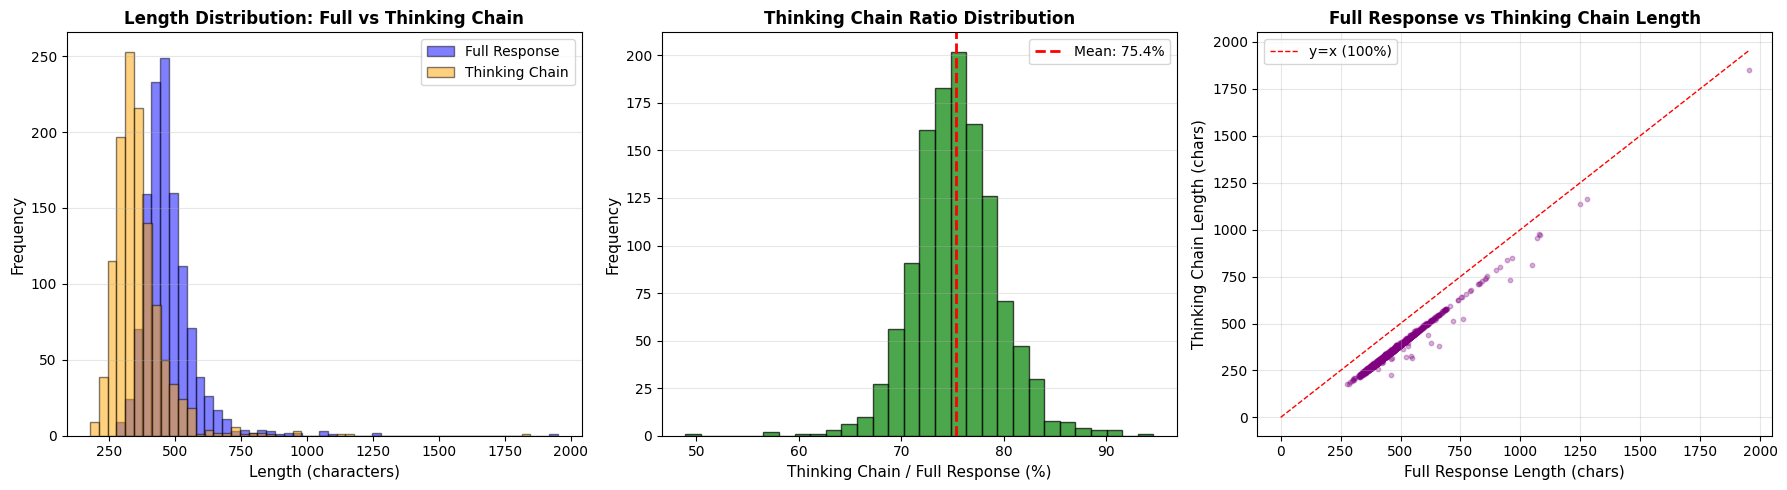


📊 Average thinking chain ratio: 75.4%
📊 Median thinking chain ratio: 75.3%


In [87]:
# 可视化思维链 vs 完整回复的对比
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 长度对比直方图
axes[0].hist([len(r) for r in all_full_responses], bins=50, alpha=0.5, label='Full Response', color='blue', edgecolor='black')
axes[0].hist([len(r) for r in all_responses], bins=50, alpha=0.5, label='Thinking Chain', color='orange', edgecolor='black')
axes[0].set_xlabel('Length (characters)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Length Distribution: Full vs Thinking Chain', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. 思维链占比分布
full_lengths = np.array([len(r) for r in all_full_responses])
thinking_lengths = np.array([len(r) for r in all_responses])
ratios = np.divide(thinking_lengths, full_lengths, where=full_lengths!=0, out=np.zeros_like(thinking_lengths, dtype=float))
ratios = ratios * 100  # 转换为百分比

axes[1].hist(ratios, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean(ratios), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(ratios):.1f}%')
axes[1].set_xlabel('Thinking Chain / Full Response (%)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Thinking Chain Ratio Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# 3. 散点图：完整长度 vs 思维链长度
axes[2].scatter(full_lengths, thinking_lengths, alpha=0.3, s=10, color='purple')
axes[2].plot([0, max(full_lengths)], [0, max(full_lengths)], 'r--', linewidth=1, label='y=x (100%)')
axes[2].set_xlabel('Full Response Length (chars)', fontsize=11)
axes[2].set_ylabel('Thinking Chain Length (chars)', fontsize=11)
axes[2].set_title('Full Response vs Thinking Chain Length', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Average thinking chain ratio: {np.mean(ratios):.1f}%")
print(f"📊 Median thinking chain ratio: {np.median(ratios):.1f}%")

回复长度统计
平均长度: 362.13 字符
中位数长度: 343.50 字符
最小长度: 178 字符
最大长度: 1848 字符
标准差: 105.68



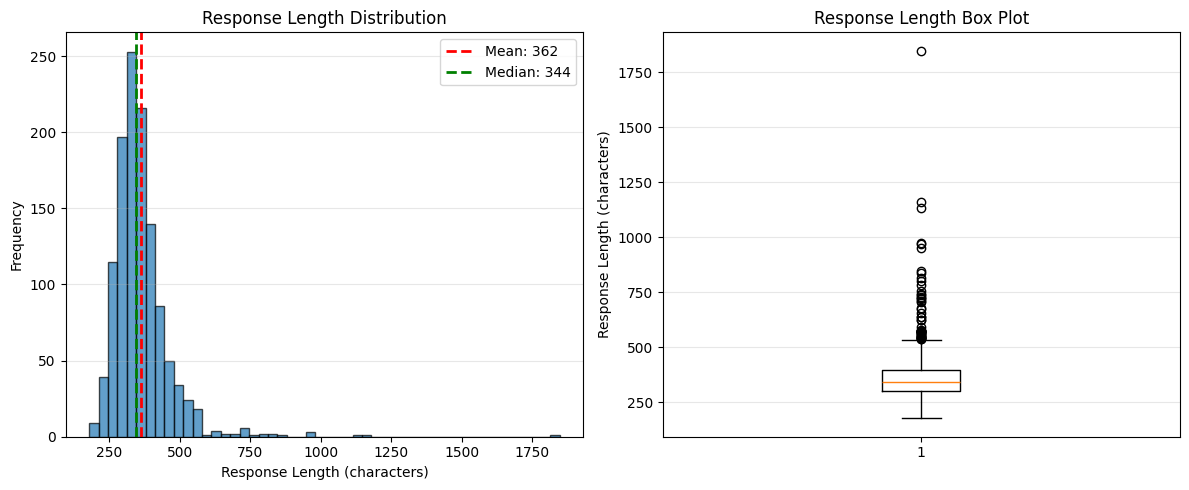

In [88]:
# 1. 统计平均回复长度
response_lengths = [len(response) for response in all_responses]

avg_length = np.mean(response_lengths)
median_length = np.median(response_lengths)
min_length = np.min(response_lengths)
max_length = np.max(response_lengths)
std_length = np.std(response_lengths)

print("=" * 50)
print("回复长度统计")
print("=" * 50)
print(f"平均长度: {avg_length:.2f} 字符")
print(f"中位数长度: {median_length:.2f} 字符")
print(f"最小长度: {min_length} 字符")
print(f"最大长度: {max_length} 字符")
print(f"标准差: {std_length:.2f}")
print()

# 绘制长度分布图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(response_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(avg_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_length:.0f}')
plt.axvline(median_length, color='green', linestyle='--', linewidth=2, label=f'Median: {median_length:.0f}')
plt.xlabel('Response Length (characters)')
plt.ylabel('Frequency')
plt.title('Response Length Distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(response_lengths, vert=True)
plt.ylabel('Response Length (characters)')
plt.title('Response Length Box Plot')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [89]:
# 2. 统计高频词汇
# 将所有回复合并
all_text = " ".join(all_responses)

# 清理文本：转换为小写并提取单词
# 只保留字母和数字组成的单词
words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

# 定义停用词（可以根据需要扩展）
stop_words = {
    'the', 'to', 'and', 'a', 'of', 'is', 'in', 'for', 'on', 'with', 'as', 'at', 
    'by', 'from', 'this', 'that', 'it', 'be', 'are', 'an', 'or', 'will', 'can',
    'i', 'you', 'your', 'we', 'my', 'me', 'he', 'she', 'they', 'them', 'their',
    'has', 'have', 'had', 'was', 'were', 'been', 'being', 'do', 'does', 'did',
    'should', 'would', 'could', 'may', 'might', 'must', 'shall', 'will',
    'am', 'so', 'if', 'but', 'not', 'no', 'yes', 'all', 'any', 'what', 'when',
    'where', 'which', 'who', 'how', 'why', 'there', 'here', 'into', 'out',
    'up', 'down', 'over', 'under', 'about', 'after', 'before', 'through'
}

# 过滤掉停用词和长度小于3的单词
filtered_words = [word for word in words if word not in stop_words and len(word) >= 3]

# 统计词频
word_counter = Counter(filtered_words)

# 获取前50个高频词
top_50_words = word_counter.most_common(50)

print("=" * 50)
print("高频词汇统计 (Top 50)")
print("=" * 50)
print(f"总词数（去除停用词）: {len(filtered_words)}")
print(f"唯一词数: {len(word_counter)}")
print()
print("排名\t词汇\t\t\t出现次数")
print("-" * 50)
for i, (word, count) in enumerate(top_50_words, 1):
    print(f"{i}\t{word:<20}\t{count}")


高频词汇统计 (Top 50)
总词数（去除停用词）: 42995
唯一词数: 2195

排名	词汇			出现次数
--------------------------------------------------
1	action              	1254
2	think               	1210
3	click               	930
4	need                	857
5	search              	553
6	goal                	544
7	since               	523
8	next                	519
9	step                	457
10	menu                	388
11	select              	351
12	button              	349
13	open                	348
14	current             	325
15	file                	319
16	first               	313
17	field               	308
18	logical             	307
19	successfully        	300
20	option              	300
21	new                 	297
22	type                	297
23	bar                 	271
24	task                	271
25	already             	268
26	proceed             	256
27	text                	252
28	page                	238
29	folder              	234
30	shows               	218
31	achieve             	216
32	visible             	210
3

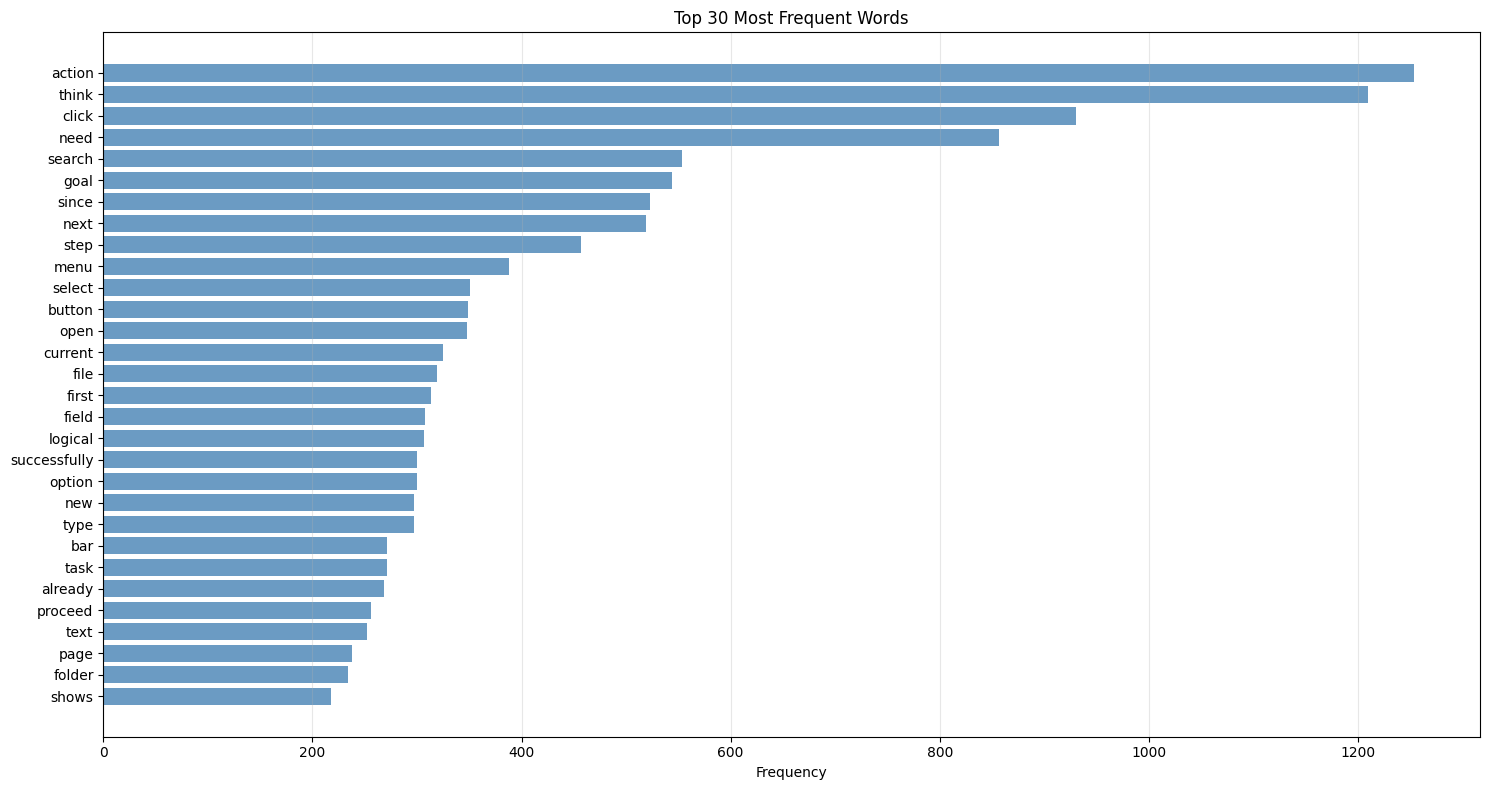


词频分布统计
出现 1254 次的词汇数量: 1
出现 1210 次的词汇数量: 1
出现 930 次的词汇数量: 1
出现 857 次的词汇数量: 1
出现 553 次的词汇数量: 1
出现 544 次的词汇数量: 1
出现 523 次的词汇数量: 1
出现 519 次的词汇数量: 1
出现 457 次的词汇数量: 1
出现 388 次的词汇数量: 1


In [90]:
# 可视化高频词汇
plt.figure(figsize=(15, 8))

# 获取前30个高频词用于可视化
top_30_words = word_counter.most_common(30)
words_list, counts_list = zip(*top_30_words)

# 创建条形图
plt.barh(range(len(words_list)), counts_list, color='steelblue', alpha=0.8)
plt.yticks(range(len(words_list)), words_list)
plt.xlabel('Frequency')
plt.title('Top 30 Most Frequent Words')
plt.gca().invert_yaxis()  # 让最高频的词在顶部
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 显示词频分布
print("\n" + "=" * 50)
print("词频分布统计")
print("=" * 50)
word_freq_distribution = Counter([count for count in word_counter.values()])
for freq in sorted(word_freq_distribution.keys(), reverse=True)[:10]:
    print(f"出现 {freq} 次的词汇数量: {word_freq_distribution[freq]}")

In [91]:
# 3. 提取和统计常见短语模板 (N-grams)
from collections import defaultdict

def extract_ngrams(text, n):
    """提取n-gram短语"""
    words = text.split()
    ngrams = []
    for i in range(len(words) - n + 1):
        ngram = ' '.join(words[i:i+n])
        ngrams.append(ngram)
    return ngrams

# 预处理文本：保留基本结构，只做简单清理
def clean_text_for_phrases(text):
    """清理文本但保留短语结构"""
    # 移除特殊字符但保留基本标点
    text = re.sub(r'[^\w\s\',.-]', ' ', text)
    # 统一多个空格
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 合并所有回复文本
all_text_for_phrases = " ".join([clean_text_for_phrases(response.lower()) for response in all_responses])

# 提取不同长度的n-grams
bigrams = extract_ngrams(all_text_for_phrases, 2)
trigrams = extract_ngrams(all_text_for_phrases, 3)
fourgrams = extract_ngrams(all_text_for_phrases, 4)
fivegrams = extract_ngrams(all_text_for_phrases, 5)

# 统计频率
bigram_counter = Counter(bigrams)
trigram_counter = Counter(trigrams)
fourgram_counter = Counter(fourgrams)
fivegram_counter = Counter(fivegrams)

print("=" * 70)
print("N-GRAM PHRASE ANALYSIS - Common Templates in Model Responses")
print("=" * 70)
print(f"Total responses analyzed: {len(all_responses)}")
print()

N-GRAM PHRASE ANALYSIS - Common Templates in Model Responses
Total responses analyzed: 1208



In [92]:
# 过滤有意义的短语（排除纯停用词组合）
def filter_meaningful_phrases(ngram_counter, min_freq=10):
    """过滤出有意义的短语模板"""
    # 扩展停用词列表，包含更多常见词
    extended_stop_words = {
        'the', 'to', 'and', 'a', 'of', 'is', 'in', 'for', 'on', 'with', 'as', 'at',
        'will', 'be', 's', 't', 'can', 'it', 'this', 'that', 'by', 'from', 'or',
        'an', 'are', 'was', 'were', 'been', 'have', 'has', 'had', 'do', 'does',
        'did', 'but', 'if', 'then', 'than', 'so', 'these', 'those', 'such'
    }
    
    filtered = []
    for phrase, count in ngram_counter.most_common(200):
        if count < min_freq:
            break
        
        words_in_phrase = phrase.split()
        
        # 检查是否全是停用词
        if all(word in extended_stop_words for word in words_in_phrase):
            continue
        
        # 检查是否有至少一个有意义的词
        if any(word not in extended_stop_words for word in words_in_phrase):
            filtered.append((phrase, count))
    
    return filtered

# 过滤各种n-grams
meaningful_bigrams = filter_meaningful_phrases(bigram_counter, min_freq=20)
meaningful_trigrams = filter_meaningful_phrases(trigram_counter, min_freq=15)
meaningful_fourgrams = filter_meaningful_phrases(fourgram_counter, min_freq=10)
meaningful_fivegrams = filter_meaningful_phrases(fivegram_counter, min_freq=8)

# 显示结果
print("\n" + "=" * 70)
print("TOP 2-WORD PHRASES (Bigrams)")
print("=" * 70)
for i, (phrase, count) in enumerate(meaningful_bigrams[:30], 1):
    print(f"{i:2d}. '{phrase:<35}' - {count:4d} times")

print("\n" + "=" * 70)
print("TOP 3-WORD PHRASES (Trigrams)")
print("=" * 70)
for i, (phrase, count) in enumerate(meaningful_trigrams[:30], 1):
    print(f"{i:2d}. '{phrase:<45}' - {count:4d} times")

print("\n" + "=" * 70)
print("TOP 4-WORD PHRASES (4-grams)")
print("=" * 70)
for i, (phrase, count) in enumerate(meaningful_fourgrams[:25], 1):
    print(f"{i:2d}. '{phrase:<50}' - {count:4d} times")

print("\n" + "=" * 70)
print("TOP 5-WORD PHRASES (5-grams)")
print("=" * 70)
for i, (phrase, count) in enumerate(meaningful_fivegrams[:20], 1):
    print(f"{i:2d}. '{phrase:<55}' - {count:4d} times")


TOP 2-WORD PHRASES (Bigrams)
 1. 'think action                       ' - 1148 times
 2. 'need to                            ' -  856 times
 3. 'action click                       ' -  795 times
 4. 'i need                             ' -  774 times
 5. 'click on                           ' -  693 times
 6. 'the goal                           ' -  415 times
 7. 'into the                           ' -  383 times
 8. 'the next                           ' -  356 times
 9. 'step is                            ' -  331 times
10. 'i should                           ' -  324 times
11. 'the current                        ' -  320 times
12. 'the search                         ' -  293 times
13. 'next logical                       ' -  286 times
14. 'logical step                       ' -  284 times
15. 'since the                          ' -  272 times
16. 'to select                          ' -  222 times
17. 'goal of                            ' -  221 times
18. 'to achieve                    

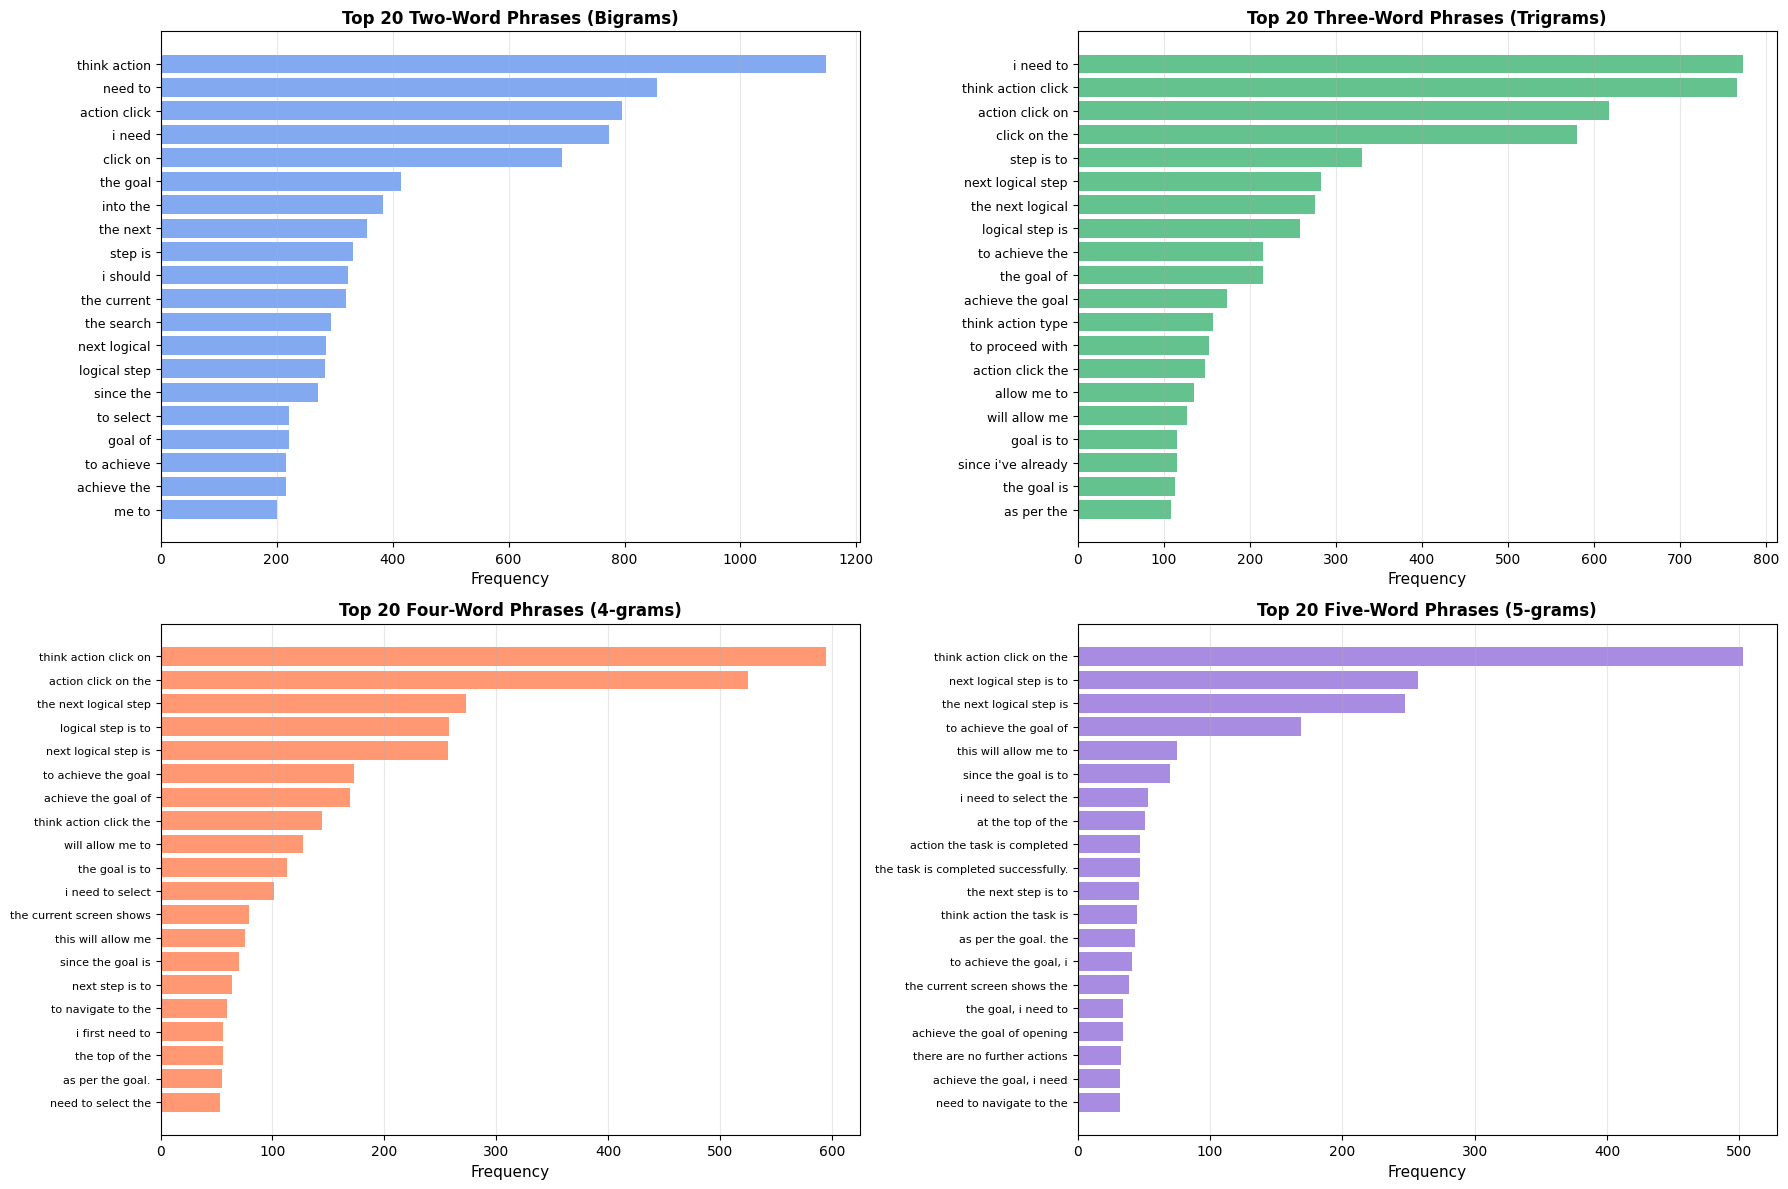

In [93]:
# 可视化常见短语模板
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Bigrams
if meaningful_bigrams:
    phrases, counts = zip(*meaningful_bigrams[:20])
    axes[0, 0].barh(range(len(phrases)), counts, color='cornflowerblue', alpha=0.8)
    axes[0, 0].set_yticks(range(len(phrases)))
    axes[0, 0].set_yticklabels(phrases, fontsize=9)
    axes[0, 0].set_xlabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Top 20 Two-Word Phrases (Bigrams)', fontsize=12, fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

# Trigrams
if meaningful_trigrams:
    phrases, counts = zip(*meaningful_trigrams[:20])
    axes[0, 1].barh(range(len(phrases)), counts, color='mediumseagreen', alpha=0.8)
    axes[0, 1].set_yticks(range(len(phrases)))
    axes[0, 1].set_yticklabels(phrases, fontsize=9)
    axes[0, 1].set_xlabel('Frequency', fontsize=11)
    axes[0, 1].set_title('Top 20 Three-Word Phrases (Trigrams)', fontsize=12, fontweight='bold')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(axis='x', alpha=0.3)

# 4-grams
if meaningful_fourgrams:
    phrases, counts = zip(*meaningful_fourgrams[:20])
    axes[1, 0].barh(range(len(phrases)), counts, color='coral', alpha=0.8)
    axes[1, 0].set_yticks(range(len(phrases)))
    axes[1, 0].set_yticklabels(phrases, fontsize=8)
    axes[1, 0].set_xlabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Top 20 Four-Word Phrases (4-grams)', fontsize=12, fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)

# 5-grams
if meaningful_fivegrams:
    phrases, counts = zip(*meaningful_fivegrams[:20])
    axes[1, 1].barh(range(len(phrases)), counts, color='mediumpurple', alpha=0.8)
    axes[1, 1].set_yticks(range(len(phrases)))
    axes[1, 1].set_yticklabels(phrases, fontsize=8)
    axes[1, 1].set_xlabel('Frequency', fontsize=11)
    axes[1, 1].set_title('Top 20 Five-Word Phrases (5-grams)', fontsize=12, fontweight='bold')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
# 句子级别的推理模式分析
import re

def split_into_sentences(text):
    """将文本分割成句子"""
    # 使用正则表达式按句号、问号、感叹号分割，但保留缩写
    sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!)\s', text)
    # 过滤掉空句子和太短的句子
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

# 定义句子级别的推理模式分类
REASONING_PATTERNS = {
    'Current State Analysis': {
        'keywords': [
            'currently', 'the current', 'at this point', 'right now', 'at present',
            'the page shows', 'i can see', 'the screen displays', 'visible',
            'already', 'appears to be', 'seems to be', 'is displayed',
            'the interface shows', 'looking at', 'observing', 'notice that'
        ],
        'description': 'Analyzing or describing the current state/situation'
    },
    
    'Goal Statement': {
        'keywords': [
            'the goal is', 'the objective', 'to achieve', 'aim is to',
            'purpose is', 'trying to', 'want to', 'the task is',
            'required to', 'in order to', 'to complete'
        ],
        'description': 'Stating the goal or objective'
    },
    
    'Next Step Planning': {
        'keywords': [
            'next step', 'the next logical step', 'i will', 'i should',
            'need to', 'must', 'have to', 'plan to', 'going to',
            'should proceed', 'will proceed', 'let me', 'first', 'then'
        ],
        'description': 'Planning or deciding the next action'
    },
    
    'Reasoning/Causality': {
        'keywords': [
            'since', 'because', 'therefore', 'thus', 'hence', 'as a result',
            'consequently', 'this means', 'which means', 'given that',
            'considering that', 'due to', 'so that', 'in order to',
            'this indicates', 'this suggests', 'this implies'
        ],
        'description': 'Explaining reasoning or causal relationships'
    },
    
    'Action Description': {
        'keywords': [
            'click on', 'type', 'select', 'press', 'enter', 'input',
            'navigate to', 'scroll', 'open', 'close', 'search for',
            'action:', 'i\'ll click', 'i\'ll type', 'i\'ll select'
        ],
        'description': 'Describing specific actions to take'
    },
    
    'Uncertainty/Hypothesis': {
        'keywords': [
            'likely', 'probably', 'possibly', 'might', 'may', 'could be',
            'seems', 'appears', 'suggests', 'indicates', 'perhaps',
            'it is possible', 'it seems', 'looks like', 'assume'
        ],
        'description': 'Expressing uncertainty or making hypotheses'
    },
    
    'Expectation': {
        'keywords': [
            'this will', 'this should', 'this allows', 'this ensures',
        ],
        'description': 'Validating or confirming actions/results'
    },

}

print("=" * 70)
print("SENTENCE-LEVEL REASONING PATTERN ANALYSIS")
print("=" * 70)
print("\n📋 Defined Pattern Categories:\n")
for i, (category, info) in enumerate(REASONING_PATTERNS.items(), 1):
    print(f"{i}. {category:<30} - {info['description']}")
    print(f"   Keywords: {', '.join(info['keywords'][:5])}...")
print()

SENTENCE-LEVEL REASONING PATTERN ANALYSIS

📋 Defined Pattern Categories:

1. Current State Analysis         - Analyzing or describing the current state/situation
   Keywords: currently, the current, at this point, right now, at present...
2. Goal Statement                 - Stating the goal or objective
   Keywords: the goal is, the objective, to achieve, aim is to, purpose is...
3. Next Step Planning             - Planning or deciding the next action
   Keywords: next step, the next logical step, i will, i should, need to...
4. Reasoning/Causality            - Explaining reasoning or causal relationships
   Keywords: since, because, therefore, thus, hence...
5. Action Description             - Describing specific actions to take
   Keywords: click on, type, select, press, enter...
6. Uncertainty/Hypothesis         - Expressing uncertainty or making hypotheses
   Keywords: likely, probably, possibly, might, may...
7. Expectation                    - Validating or confirming actions/res

In [95]:
# 句子分类函数（支持多标签）
def classify_sentence(sentence, min_keyword_threshold=1):
    """
    根据关键词对句子进行分类，支持多标签分类
    
    Args:
        sentence: 待分类的句子
        min_keyword_threshold: 最少需要匹配的关键词数量才算匹配该类别
    
    Returns:
        categories: 匹配的所有类别列表
        all_matches: 所有匹配详情的字典
    """
    sentence_lower = sentence.lower()
    
    # 记录匹配到的所有类别和匹配的关键词
    all_matches = {}
    
    for category, info in REASONING_PATTERNS.items():
        matched_keywords = []
        
        for keyword in info['keywords']:
            if keyword in sentence_lower:
                matched_keywords.append(keyword)
        
        if len(matched_keywords) >= min_keyword_threshold:
            all_matches[category] = {
                'count': len(matched_keywords),
                'keywords': matched_keywords
            }
    
    # 返回所有匹配的类别
    if all_matches:
        # 按匹配关键词数量排序
        categories = sorted(all_matches.keys(), key=lambda x: all_matches[x]['count'], reverse=True)
        return categories, all_matches
    else:
        return ['Other/Unclassified'], {}

# 提取所有句子并分类
print("\n" + "=" * 70)
print("Extracting and classifying sentences from thinking chains...")
print("(Multi-label classification enabled)")
print("=" * 70)

all_sentences = []
sentence_classifications = {cat: [] for cat in REASONING_PATTERNS.keys()}
sentence_classifications['Other/Unclassified'] = []

# 用于统计多标签
multi_label_stats = {
    'single_label': 0,
    'multi_label': 0,
    'max_labels': 0
}

total_sentences = 0
total_label_assignments = 0  # 总的标签分配数（一个句子可能有多个标签）

for response in all_responses:
    if len(response) > 0:
        sentences = split_into_sentences(response)
        for sentence in sentences:
            categories, matches = classify_sentence(sentence)
            
            # 记录句子信息
            all_sentences.append({
                'text': sentence,
                'categories': categories,  # 现在是列表
                'matched_details': matches
            })
            
            # 统计多标签情况
            num_labels = len(categories)
            if num_labels == 1:
                multi_label_stats['single_label'] += 1
            else:
                multi_label_stats['multi_label'] += 1
            multi_label_stats['max_labels'] = max(multi_label_stats['max_labels'], num_labels)
            
            # 将句子添加到所有匹配的类别中
            for category in categories:
                sentence_classifications[category].append(sentence)
                total_label_assignments += 1
            
            total_sentences += 1

print(f"\n✅ Extracted and classified {total_sentences} sentences from {len(all_responses)} responses")
print(f"   Average sentences per response: {total_sentences/len([r for r in all_responses if len(r) > 0]):.1f}")

print(f"\n📊 Multi-label Statistics:")
print(f"   Sentences with single label: {multi_label_stats['single_label']} ({multi_label_stats['single_label']/total_sentences*100:.1f}%)")
print(f"   Sentences with multiple labels: {multi_label_stats['multi_label']} ({multi_label_stats['multi_label']/total_sentences*100:.1f}%)")
print(f"   Maximum labels on one sentence: {multi_label_stats['max_labels']}")
print(f"   Average labels per sentence: {total_label_assignments/total_sentences:.2f}")

# 统计各类别的句子数量
print("\n" + "=" * 70)
print("SENTENCE CLASSIFICATION DISTRIBUTION")
print("(Note: Sentences can belong to multiple categories)")
print("=" * 70)
print()

category_counts = [(cat, len(sentences)) for cat, sentences in sentence_classifications.items()]
category_counts.sort(key=lambda x: x[1], reverse=True)

for i, (category, count) in enumerate(category_counts, 1):
    # 注意：这里的百分比可能总和超过100%，因为一个句子可能属于多个类别
    percentage = (count / total_sentences) * 100 if total_sentences > 0 else 0
    print(f"{i}. {category:<30} : {count:5d} assignments ({percentage:5.2f}%)")

print(f"\n💡 Total label assignments: {total_label_assignments} (avg {total_label_assignments/total_sentences:.2f} per sentence)")


Extracting and classifying sentences from thinking chains...
(Multi-label classification enabled)

✅ Extracted and classified 4226 sentences from 1208 responses
   Average sentences per response: 3.5

📊 Multi-label Statistics:
   Sentences with single label: 2436 (57.6%)
   Sentences with multiple labels: 1790 (42.4%)
   Maximum labels on one sentence: 5
   Average labels per sentence: 1.65

SENTENCE CLASSIFICATION DISTRIBUTION
(Note: Sentences can belong to multiple categories)

1. Action Description             :  2520 assignments (59.63%)
2. Next Step Planning             :  1718 assignments (40.65%)
3. Current State Analysis         :   874 assignments (20.68%)
4. Reasoning/Causality            :   567 assignments (13.42%)
5. Goal Statement                 :   480 assignments (11.36%)
6. Other/Unclassified             :   357 assignments ( 8.45%)
7. Uncertainty/Hypothesis         :   317 assignments ( 7.50%)
8. Expectation                    :   142 assignments ( 3.36%)

💡 Total l

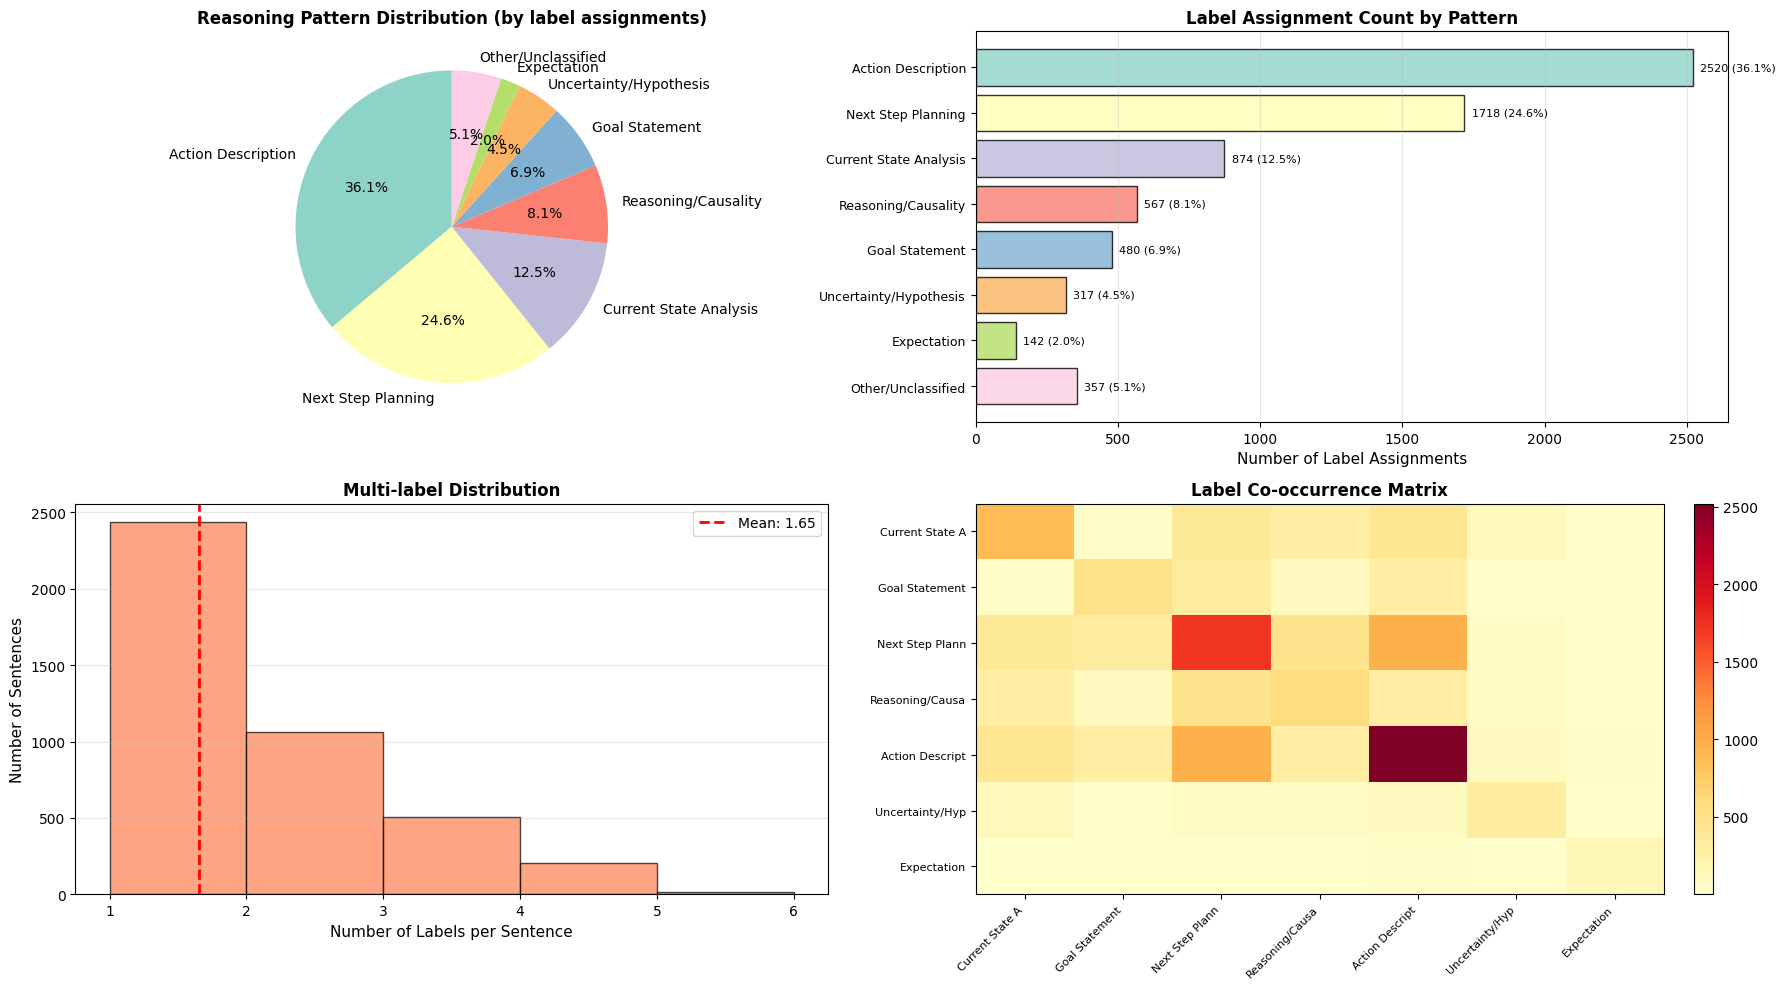


MOST COMMON LABEL COMBINATIONS

Top 15 Multi-label Combinations:
 1. Action Description + Next Step Planning
    Count: 443 (24.7% of multi-label sentences)

 2. Action Description + Current State Analysis
    Count: 159 (8.9% of multi-label sentences)

 3. Action Description + Goal Statement + Next Step Planning
    Count: 155 (8.7% of multi-label sentences)

 4. Action Description + Current State Analysis + Next Step Planning + Reasoning/Causality
    Count: 118 (6.6% of multi-label sentences)

 5. Current State Analysis + Next Step Planning + Reasoning/Causality
    Count: 86 (4.8% of multi-label sentences)

 6. Goal Statement + Next Step Planning
    Count: 81 (4.5% of multi-label sentences)

 7. Next Step Planning + Reasoning/Causality
    Count: 77 (4.3% of multi-label sentences)

 8. Action Description + Goal Statement
    Count: 73 (4.1% of multi-label sentences)

 9. Action Description + Current State Analysis + Next Step Planning
    Count: 72 (4.0% of multi-label sentences)

In [96]:
# 可视化句子级别的模式分布（多标签版本）
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. 饼图 - 整体分布（基于标签分配）
categories = [cat for cat, _ in category_counts if cat != 'Other/Unclassified']
counts = [count for cat, count in category_counts if cat != 'Other/Unclassified']
other_count = next((count for cat, count in category_counts if cat == 'Other/Unclassified'), 0)

if other_count > 0:
    categories.append('Other/Unclassified')
    counts.append(other_count)

colors = plt.cm.Set3(range(len(categories)))
axes[0, 0].pie(counts, labels=categories, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0, 0].set_title('Reasoning Pattern Distribution (by label assignments)', fontsize=12, fontweight='bold')

# 2. 条形图 - 详细数量
axes[0, 1].barh(range(len(categories)), counts, color=colors, edgecolor='black', alpha=0.8)
axes[0, 1].set_yticks(range(len(categories)))
axes[0, 1].set_yticklabels(categories, fontsize=9)
axes[0, 1].set_xlabel('Number of Label Assignments', fontsize=11)
axes[0, 1].set_title('Label Assignment Count by Pattern', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

for i, (cat, count) in enumerate(zip(categories, counts)):
    percentage = (count / total_label_assignments) * 100
    axes[0, 1].text(count + max(counts)*0.01, i, f'{count} ({percentage:.1f}%)', 
                va='center', fontsize=8)

# 3. 多标签分布直方图
label_counts_per_sentence = [len(s['categories']) for s in all_sentences]
axes[1, 0].hist(label_counts_per_sentence, bins=range(1, max(label_counts_per_sentence)+2), 
                edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Number of Labels per Sentence', fontsize=11)
axes[1, 0].set_ylabel('Number of Sentences', fontsize=11)
axes[1, 0].set_title('Multi-label Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 添加统计信息
avg_labels = np.mean(label_counts_per_sentence)
axes[1, 0].axvline(avg_labels, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_labels:.2f}')
axes[1, 0].legend()

# 4. 标签共现矩阵（热力图）
# 统计哪些标签经常一起出现
import pandas as pd

# 创建共现矩阵
pattern_names = list(REASONING_PATTERNS.keys())
cooccurrence_matrix = np.zeros((len(pattern_names), len(pattern_names)))

for sent in all_sentences:
    cats = [c for c in sent['categories'] if c != 'Other/Unclassified']
    for i, cat1 in enumerate(pattern_names):
        for j, cat2 in enumerate(pattern_names):
            if cat1 in cats and cat2 in cats:
                cooccurrence_matrix[i, j] += 1

# 绘制热力图
im = axes[1, 1].imshow(cooccurrence_matrix, cmap='YlOrRd', aspect='auto')
axes[1, 1].set_xticks(range(len(pattern_names)))
axes[1, 1].set_yticks(range(len(pattern_names)))
axes[1, 1].set_xticklabels([name[:15] for name in pattern_names], rotation=45, ha='right', fontsize=8)
axes[1, 1].set_yticklabels([name[:15] for name in pattern_names], fontsize=8)
axes[1, 1].set_title('Label Co-occurrence Matrix', fontsize=12, fontweight='bold')

# 添加colorbar
plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# 打印最常见的标签组合
print("\n" + "=" * 70)
print("MOST COMMON LABEL COMBINATIONS")
print("=" * 70)

from collections import Counter
label_combinations = Counter()
for sent in all_sentences:
    cats = tuple(sorted([c for c in sent['categories'] if c != 'Other/Unclassified']))
    if len(cats) > 1:  # 只统计多标签的
        label_combinations[cats] += 1

print("\nTop 15 Multi-label Combinations:")
for i, (combo, count) in enumerate(label_combinations.most_common(15), 1):
    percentage = (count / multi_label_stats['multi_label']) * 100 if multi_label_stats['multi_label'] > 0 else 0
    print(f"{i:2d}. {' + '.join(combo)}")
    print(f"    Count: {count} ({percentage:.1f}% of multi-label sentences)\n")

In [97]:
# 展示每个类别的示例句子（多标签版本）
print("\n" + "=" * 70)
print("EXAMPLE SENTENCES FOR EACH REASONING PATTERN")
print("(Showing sentences where this pattern is PRIMARY)")
print("=" * 70)

for category in REASONING_PATTERNS.keys():
    # 找到以该类别为主要标签的句子（即该类别是第一个匹配的）
    primary_sentences = [s['text'] for s in all_sentences if s['categories'][0] == category]
    
    if len(primary_sentences) > 0:
        print(f"\n{'='*70}")
        print(f"📌 {category.upper()}")
        print(f"   {REASONING_PATTERNS[category]['description']}")
        print(f"   Total as primary label: {len(primary_sentences)} sentences")
        print(f"{'='*70}")
        
        # 选择中等长度的句子作为示例
        sorted_sentences = sorted(primary_sentences, key=len)
        mid_point = len(sorted_sentences) // 2
        start = max(0, mid_point - 2)
        end = min(len(sorted_sentences), mid_point + 3)
        examples = sorted_sentences[start:end]
        
        for i, sentence in enumerate(examples[:5], 1):
            # 找到这个句子的所有标签
            sent_info = next(s for s in all_sentences if s['text'] == sentence)
            all_cats = sent_info['categories']
            
            # 截断过长的句子
            display_sentence = sentence if len(sentence) <= 150 else sentence[:150] + "..."
            print(f"\n{i}. {display_sentence}")
            
            # 如果有多个标签，显示其他标签
            if len(all_cats) > 1:
                other_cats = [c for c in all_cats if c != category]
                print(f"   └─ Also tagged as: {', '.join(other_cats)}")

# 展示多标签句子的特殊示例
print(f"\n{'='*70}")
print(f"📌 MULTI-LABEL EXAMPLES")
print(f"   Sentences that belong to multiple reasoning patterns")
print(f"{'='*70}")

# 找出标签最多的句子
multi_label_sentences = sorted(
    [s for s in all_sentences if len(s['categories']) > 1 and 'Other/Unclassified' not in s['categories']], 
    key=lambda x: len(x['categories']), 
    reverse=True
)[:10]

for i, sent_info in enumerate(multi_label_sentences, 1):
    sentence = sent_info['text']
    categories = sent_info['categories']
    
    display_sentence = sentence if len(sentence) <= 120 else sentence[:120] + "..."
    print(f"\n{i}. [{len(categories)} labels] {display_sentence}")
    print(f"   Labels: {' + '.join(categories)}")
    
    # 显示每个标签匹配的关键词
    for cat in categories:
        if cat in sent_info['matched_details']:
            keywords = sent_info['matched_details'][cat]['keywords'][:2]
            print(f"   └─ {cat}: {', '.join(keywords)}")


EXAMPLE SENTENCES FOR EACH REASONING PATTERN
(Showing sentences where this pattern is PRIMARY)

📌 CURRENT STATE ANALYSIS
   Analyzing or describing the current state/situation
   Total as primary label: 725 sentences

1. The next logical step is to save these changes to ensure the highlighting persists beyond the current session.
   └─ Also tagged as: Next Step Planning

2. The 'Flight + Hotel' tab is visible in the navigation bar, which seems to be the correct choice for this task.
   └─ Also tagged as: Uncertainty/Hypothesis

3. The cursor is already in the correct place in the description field, so I should type the required text there.
   └─ Also tagged as: Next Step Planning, Action Description

4. The current view shows that the dropdown is open, displaying various rating options including '4.0' and '4.5'.
   └─ Also tagged as: Action Description

5. The presence of this button indicates that it's possible to make these changes directly from the current view.
   └─ Also tagged a

In [98]:
# 分析典型的推理链序列模式（多标签版本）
print("\n" + "=" * 70)
print("TYPICAL REASONING CHAIN SEQUENCES")
print("(Using primary labels for sequence analysis)")
print("=" * 70)
print("\nAnalyzing the sequence of reasoning patterns in complete responses...")

# 为每个回复生成序列（使用主要标签）
response_sequences = []
for response in all_responses:
    if len(response) > 0:
        sentences = split_into_sentences(response)
        if len(sentences) >= 2:  # 至少有2个句子
            sequence = []
            for sentence in sentences:
                categories, _ = classify_sentence(sentence)
                # 使用第一个（主要）标签
                sequence.append(categories[0])
            response_sequences.append(sequence)

# 统计常见的序列模式（前3个句子的模式）
sequence_patterns = Counter()
for seq in response_sequences:
    if len(seq) >= 3:
        pattern = ' → '.join(seq[:3])
        sequence_patterns[pattern] += 1
    elif len(seq) == 2:
        pattern = ' → '.join(seq[:2])
        sequence_patterns[pattern] += 1

print(f"\n✅ Analyzed {len(response_sequences)} responses with multiple sentences")
print(f"\nTop 15 Most Common Reasoning Sequences (first 2-3 sentences):")
print("=" * 70)

for i, (pattern, count) in enumerate(sequence_patterns.most_common(15), 1):
    percentage = (count / len(response_sequences)) * 100
    print(f"{i:2d}. {pattern}")
    print(f"    Count: {count} ({percentage:.1f}%)")
    print()

# 计算每个位置最常见的模式
print("\n" + "=" * 70)
print("MOST COMMON PATTERN AT EACH POSITION IN REASONING CHAIN")
print("(Primary labels only)")
print("=" * 70)

position_patterns = [Counter(), Counter(), Counter(), Counter(), Counter()]
for seq in response_sequences:
    for i, category in enumerate(seq[:5]):  # 分析前5个句子
        position_patterns[i][category] += 1

for i, counter in enumerate(position_patterns, 1):
    if counter:
        print(f"\n📍 Position {i} (first sentence = position 1):")
        for category, count in counter.most_common(5):
            percentage = (count / sum(counter.values())) * 100
            print(f"   {category:<30} : {count:4d} times ({percentage:5.1f}%)")

# 额外分析：多标签在序列中的分布
print("\n" + "=" * 70)
print("MULTI-LABEL DISTRIBUTION ACROSS POSITIONS")
print("=" * 70)

position_multi_label_stats = []
for response in all_responses:
    if len(response) > 0:
        sentences = split_into_sentences(response)
        for pos, sentence in enumerate(sentences[:5]):
            categories, _ = classify_sentence(sentence)
            if pos >= len(position_multi_label_stats):
                position_multi_label_stats.append([])
            position_multi_label_stats[pos].append(len(categories))

print("\nAverage number of labels per sentence by position:")
for i, labels_at_pos in enumerate(position_multi_label_stats, 1):
    avg_labels = np.mean(labels_at_pos)
    print(f"   Position {i}: {avg_labels:.2f} labels on average")


TYPICAL REASONING CHAIN SEQUENCES
(Using primary labels for sequence analysis)

Analyzing the sequence of reasoning patterns in complete responses...

✅ Analyzed 1208 responses with multiple sentences

Top 15 Most Common Reasoning Sequences (first 2-3 sentences):
 1. Next Step Planning → Current State Analysis → Action Description
    Count: 226 (18.7%)

 2. Next Step Planning → Action Description → Action Description
    Count: 66 (5.5%)

 3. Next Step Planning → Current State Analysis → Next Step Planning
    Count: 63 (5.2%)

 4. Next Step Planning → Next Step Planning → Action Description
    Count: 58 (4.8%)

 5. Goal Statement → Current State Analysis → Action Description
    Count: 44 (3.6%)

 6. Next Step Planning → Expectation → Action Description
    Count: 34 (2.8%)

 7. Next Step Planning → Other/Unclassified → Action Description
    Count: 32 (2.6%)

 8. Next Step Planning → Uncertainty/Hypothesis → Action Description
    Count: 29 (2.4%)

 9. Action Description → Current

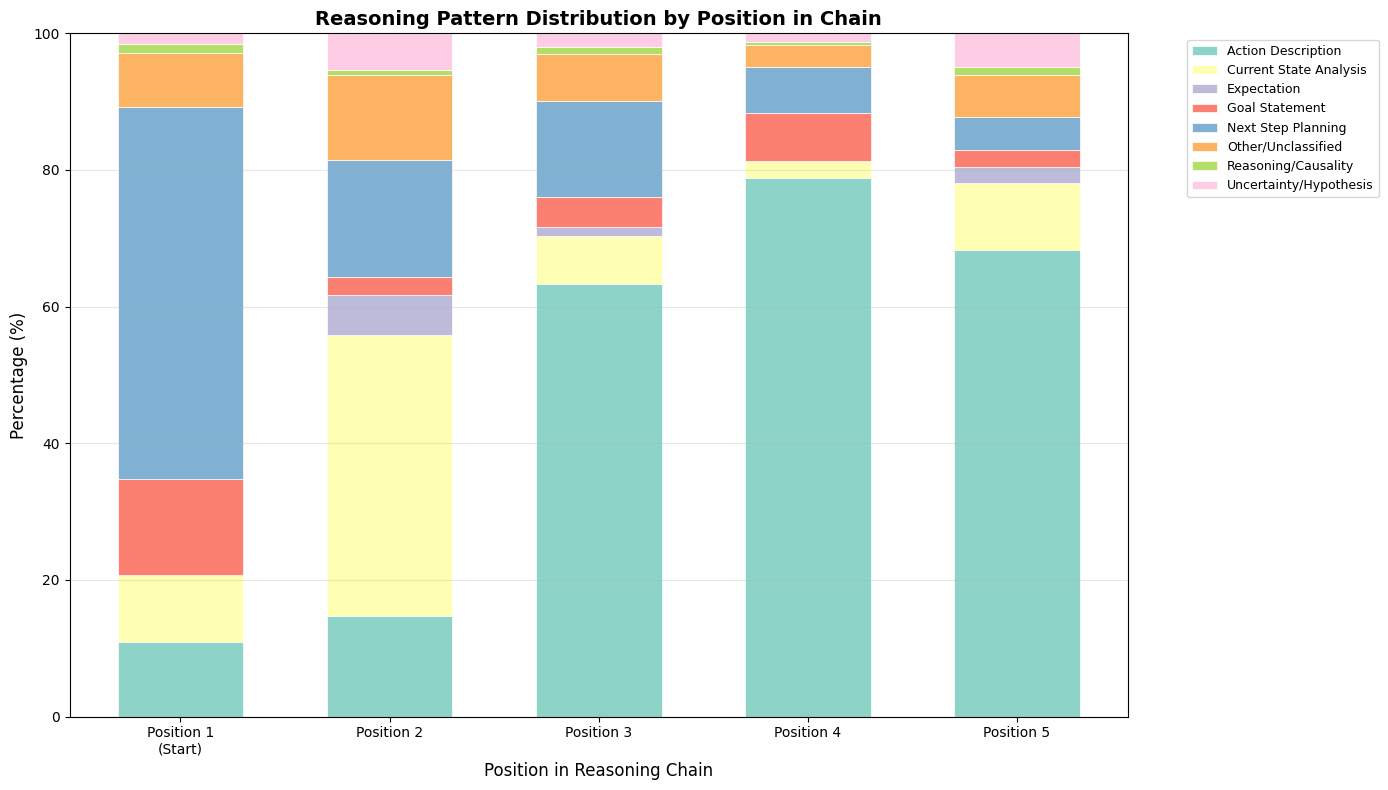

In [99]:
# 可视化推理链位置分布
fig, ax = plt.subplots(figsize=(14, 8))

# 准备数据
positions = ['Position 1\n(Start)', 'Position 2', 'Position 3', 'Position 4', 'Position 5']
# 获取所有唯一的类别
all_categories = set()
for counter in position_patterns:
    all_categories.update(counter.keys())
all_categories = sorted(list(all_categories))

# 为每个类别创建一组数据
category_colors = plt.cm.Set3(range(len(all_categories)))
color_map = {cat: category_colors[i] for i, cat in enumerate(all_categories)}

# 创建堆叠条形图
bottoms = [0] * len(position_patterns)
bar_width = 0.6

for category in all_categories:
    values = []
    for counter in position_patterns:
        total = sum(counter.values())
        value = (counter[category] / total * 100) if total > 0 else 0
        values.append(value)
    
    ax.bar(range(len(position_patterns)), values, bar_width, 
           bottom=bottoms, label=category, color=color_map[category], 
           edgecolor='white', linewidth=0.5)
    
    bottoms = [b + v for b, v in zip(bottoms, values)]

ax.set_xticks(range(len(position_patterns)))
ax.set_xticklabels(positions)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Position in Reasoning Chain', fontsize=12)
ax.set_title('Reasoning Pattern Distribution by Position in Chain', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
# 展示完整的推理链示例（带句子级别多标签标注）
print("\n" + "=" * 70)
print("COMPLETE REASONING CHAIN EXAMPLES (with multi-label annotations)")
print("=" * 70)

# 找几个有代表性的推理链
example_count = 0
max_examples = 3

for response in all_responses:
    if len(response) > 0:
        sentences = split_into_sentences(response)
        
        # 选择有3-5个句子的作为示例
        if 3 <= len(sentences) <= 5:
            example_count += 1
            
            print(f"\n{'='*70}")
            print(f"EXAMPLE {example_count}")
            print(f"{'='*70}")
            
            for i, sentence in enumerate(sentences, 1):
                categories, matches = classify_sentence(sentence)
                
                # 颜色编码（用emoji表示主要标签）
                emoji_map = {
                    'Current State Analysis': '🔍',
                    'Goal Statement': '🎯',
                    'Next Step Planning': '📋',
                    'Reasoning/Causality': '🧠',
                    'Decision Making': '⚖️',
                    'Action Description': '⚡',
                    'Uncertainty/Hypothesis': '❓',
                    'Validation/Confirmation': '✅',
                    'Other/Unclassified': '⭕'
                }
                
                primary_category = categories[0]
                emoji = emoji_map.get(primary_category, '⭕')
                
                # 构建标签字符串
                if len(categories) == 1:
                    label_str = f"[{primary_category}]"
                else:
                    other_cats = categories[1:]
                    label_str = f"[{primary_category} + {len(other_cats)} more]"
                
                print(f"\n{emoji} Sentence {i}: {label_str}")
                print(f"   {sentence}")
                
                # 显示所有标签
                if len(categories) > 1:
                    print(f"   📑 All labels: {' | '.join(categories)}")
                
                # 显示匹配的关键词（主要标签的）
                if primary_category in matches:
                    keywords = matches[primary_category]['keywords'][:3]
                    print(f"   └─ Matched keywords ({primary_category}): {', '.join(keywords)}")
            
            if example_count >= max_examples:
                break

print("\n" + "=" * 70)
print("Legend:")
print("=" * 70)
for category, emoji in {
    'Current State Analysis': '🔍',
    'Goal Statement': '🎯',
    'Next Step Planning': '📋',
    'Reasoning/Causality': '🧠',
    'Decision Making': '⚖️',
    'Action Description': '⚡',
    'Uncertainty/Hypothesis': '❓',
    'Validation/Confirmation': '✅'
}.items():
    print(f"{emoji} = {category}")

print("\n" + "=" * 70)
print("💡 Multi-label Insights:")
print("=" * 70)
print("""
Multi-label classification reveals that sentences often serve multiple functions:
- A sentence can DESCRIBE current state while also PLANNING the next step
- A sentence can STATE a goal while also providing REASONING
- Complex sentences blend OBSERVATION, REASONING, and ACTION planning

This reflects the natural complexity of human reasoning, where thoughts
are not strictly compartmentalized but fluidly combine multiple cognitive
functions in single utterances.
""")


COMPLETE REASONING CHAIN EXAMPLES (with multi-label annotations)

EXAMPLE 1

📋 Sentence 1: [Next Step Planning + 1 more]
   To achieve the goal of accessing the United Airlines website and navigating to the 'Map search' feature, I first need to ensure that the website is fully loaded and responsive.
   📑 All labels: Next Step Planning | Goal Statement
   └─ Matched keywords (Next Step Planning): need to, first

🔍 Sentence 2: [Current State Analysis + 3 more]
   Since the page appears to be loading correctly, the next logical step would be to look for navigation options related to flight searches or map features.
   📑 All labels: Current State Analysis | Next Step Planning | Reasoning/Causality | Uncertainty/Hypothesis
   └─ Matched keywords (Current State Analysis): appears to be

❓ Sentence 3: [Uncertainty/Hypothesis]
   Typically, such features might be found under sections like 'Travel info', 'Deals', or within a search bar on the homepage.
   └─ Matched keywords (Uncertainty/Hypot

In [106]:
# ============================================================================
# 子句级别的推理模式分析（CLAUSE-LEVEL ANALYSIS）
# ============================================================================
import re

def split_into_clauses(text):
    """
    将文本分割成子句（clauses）
    使用逗号、分号、连词等作为分隔符
    """
    # 首先按句号、问号、感叹号分割成句子
    sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!)\s', text)
    
    all_clauses = []
    for sentence in sentences:
        # 在每个句子内部，按逗号、分号、冒号、and/but/or等分割成子句
        # 保留一些常见的短语结构（如 "in order to", "such as"）
        clause_pattern = r'(?:,\s*|;\s*|:\s*(?![^\(]*\))|(?:\s+(?:and|but|or|while|whereas|although|though)\s+))'
        clauses = re.split(clause_pattern, sentence)
        
        # 清理并过滤子句
        for clause in clauses:
            clause = clause.strip()
            # 过滤掉太短的子句（少于15个字符）和纯标点
            if len(clause) >= 15 and not re.match(r'^[\W_]+$', clause):
                all_clauses.append(clause)
    
    return all_clauses

# 定义子句级别的推理模式分类（添加 Knowledge Recall）
CLAUSE_REASONING_PATTERNS = {
    'Current State Analysis': {
        'keywords': [
            'currently', 'the current', 'at this point', 'right now', 'at present',
            'the page shows', 'i can see', 'the screen displays', 'visible',
            'already', 'appears to be', 'seems to be', 'is displayed',
            'the interface shows', 'looking at', 'observing', 'notice that',
            'shows', 'displaying', 'showing'
        ],
        'description': 'Analyzing or describing the current state/situation'
    },
    
    'Goal Statement': {
        'keywords': [
            'the goal is', 'the objective', 'to achieve', 'aim is to',
            'purpose is', 'trying to', 'want to', 'the task is',
            'required to', 'in order to', 'to complete', 'goal of'
        ],
        'description': 'Stating the goal or objective'
    },
    
    'Next Step Planning': {
        'keywords': [
            'next step', 'the next logical step', 'i will', 'i should',
            'need to', 'must', 'have to', 'plan to', 'going to',
            'should proceed', 'will proceed', 'let me', 'first', 'then',
            'next logical', 'logical step'
        ],
        'description': 'Planning or deciding the next action'
    },
    
    'Reasoning/Causality': {
        'keywords': [
            'since', 'because', 'therefore', 'thus', 'hence', 'as a result',
            'consequently', 'this means', 'which means', 'given that',
            'considering that', 'due to', 'so that',
            'this indicates', 'this suggests', 'this implies'
        ],
        'description': 'Explaining reasoning or causal relationships'
    },
    
    'Action Description': {
        'keywords': [
            'click on', 'type', 'select', 'press', 'enter', 'input',
            'navigate to', 'scroll', 'open', 'close', 'search for',
            'action:', 'i\'ll click', 'i\'ll type', 'i\'ll select',
            'click the', 'clicking'
        ],
        'description': 'Describing specific actions to take'
    },
    
    'Expectation': {
        'keywords': [
            'this will', 'this should', 'this allows', 'this ensures',
            'will allow', 'should allow', 'would allow'
        ],
        'description': 'Stating expected outcomes or effects'
    },
    
    'Knowledge Recall': {
        'keywords': [
            'typically', 'usually', 'generally', 'commonly', 'often',
            'in most cases', 'most likely', 'normally', 'as expected',
            'such as', 'for example',
            'like', 'including', 'such features', 'these types',
            'this type of', 'similar to', 'known as', 'called'
        ],
        'description': 'Recalling general knowledge, patterns, or common practices'
    },
}

print("=" * 70)
print("CLAUSE-LEVEL REASONING PATTERN ANALYSIS")
print("=" * 70)
print("\n📋 Defined Pattern Categories (with Knowledge Recall):\n")
for i, (category, info) in enumerate(CLAUSE_REASONING_PATTERNS.items(), 1):
    print(f"{i}. {category:<30} - {info['description']}")
    print(f"   Keywords: {', '.join(info['keywords'][:5])}...")
print()

CLAUSE-LEVEL REASONING PATTERN ANALYSIS

📋 Defined Pattern Categories (with Knowledge Recall):

1. Current State Analysis         - Analyzing or describing the current state/situation
   Keywords: currently, the current, at this point, right now, at present...
2. Goal Statement                 - Stating the goal or objective
   Keywords: the goal is, the objective, to achieve, aim is to, purpose is...
3. Next Step Planning             - Planning or deciding the next action
   Keywords: next step, the next logical step, i will, i should, need to...
4. Reasoning/Causality            - Explaining reasoning or causal relationships
   Keywords: since, because, therefore, thus, hence...
5. Action Description             - Describing specific actions to take
   Keywords: click on, type, select, press, enter...
6. Expectation                    - Stating expected outcomes or effects
   Keywords: this will, this should, this allows, this ensures, will allow...
7. Knowledge Recall               

In [107]:
# 子句分类函数（支持多标签）
def classify_clause(clause, min_keyword_threshold=1):
    """
    根据关键词对子句进行分类，支持多标签分类
    
    Args:
        clause: 待分类的子句
        min_keyword_threshold: 最少需要匹配的关键词数量才算匹配该类别
    
    Returns:
        categories: 匹配的所有类别列表
        all_matches: 所有匹配详情的字典
    """
    clause_lower = clause.lower()
    
    # 记录匹配到的所有类别和匹配的关键词
    all_matches = {}
    
    for category, info in CLAUSE_REASONING_PATTERNS.items():
        matched_keywords = []
        
        for keyword in info['keywords']:
            if keyword in clause_lower:
                matched_keywords.append(keyword)
        
        if len(matched_keywords) >= min_keyword_threshold:
            all_matches[category] = {
                'count': len(matched_keywords),
                'keywords': matched_keywords
            }
    
    # 返回所有匹配的类别
    if all_matches:
        # 按匹配关键词数量排序
        categories = sorted(all_matches.keys(), key=lambda x: all_matches[x]['count'], reverse=True)
        return categories, all_matches
    else:
        return ['Other/Unclassified'], {}

# 提取所有子句并分类
print("\n" + "=" * 70)
print("Extracting and classifying clauses from thinking chains...")
print("(Multi-label classification enabled)")
print("=" * 70)

all_clauses = []
clause_classifications = {cat: [] for cat in CLAUSE_REASONING_PATTERNS.keys()}
clause_classifications['Other/Unclassified'] = []

# 用于统计多标签
clause_multi_label_stats = {
    'single_label': 0,
    'multi_label': 0,
    'max_labels': 0
}

total_clauses = 0
total_clause_label_assignments = 0  # 总的标签分配数

for response in all_responses:
    if len(response) > 0:
        clauses = split_into_clauses(response)
        for clause in clauses:
            categories, matches = classify_clause(clause)
            
            # 记录子句信息
            all_clauses.append({
                'text': clause,
                'categories': categories,
                'matched_details': matches
            })
            
            # 统计多标签情况
            num_labels = len(categories)
            if num_labels == 1:
                clause_multi_label_stats['single_label'] += 1
            else:
                clause_multi_label_stats['multi_label'] += 1
            clause_multi_label_stats['max_labels'] = max(clause_multi_label_stats['max_labels'], num_labels)
            
            # 将子句添加到所有匹配的类别中
            for category in categories:
                clause_classifications[category].append(clause)
                total_clause_label_assignments += 1
            
            total_clauses += 1

print(f"\n✅ Extracted and classified {total_clauses} clauses from {len(all_responses)} responses")
print(f"   Average clauses per response: {total_clauses/len([r for r in all_responses if len(r) > 0]):.1f}")
print(f"   (Compare: {total_sentences} sentences, {total_clauses/total_sentences:.2f}x more clauses)")

print(f"\n📊 Multi-label Statistics:")
print(f"   Clauses with single label: {clause_multi_label_stats['single_label']} ({clause_multi_label_stats['single_label']/total_clauses*100:.1f}%)")
print(f"   Clauses with multiple labels: {clause_multi_label_stats['multi_label']} ({clause_multi_label_stats['multi_label']/total_clauses*100:.1f}%)")
print(f"   Maximum labels on one clause: {clause_multi_label_stats['max_labels']}")
print(f"   Average labels per clause: {total_clause_label_assignments/total_clauses:.2f}")

# 统计各类别的子句数量
print("\n" + "=" * 70)
print("CLAUSE CLASSIFICATION DISTRIBUTION")
print("(Note: Clauses can belong to multiple categories)")
print("=" * 70)
print()

clause_category_counts = [(cat, len(clauses_list)) for cat, clauses_list in clause_classifications.items()]
clause_category_counts.sort(key=lambda x: x[1], reverse=True)

for i, (category, count) in enumerate(clause_category_counts, 1):
    percentage = (count / total_clauses) * 100 if total_clauses > 0 else 0
    print(f"{i}. {category:<30} : {count:5d} assignments ({percentage:5.2f}%)")

print(f"\n💡 Total label assignments: {total_clause_label_assignments} (avg {total_clause_label_assignments/total_clauses:.2f} per clause)")


Extracting and classifying clauses from thinking chains...
(Multi-label classification enabled)

✅ Extracted and classified 8242 clauses from 1208 responses
   Average clauses per response: 6.8
   (Compare: 4226 sentences, 1.95x more clauses)

📊 Multi-label Statistics:
   Clauses with single label: 6599 (80.1%)
   Clauses with multiple labels: 1643 (19.9%)
   Maximum labels on one clause: 4
   Average labels per clause: 1.22

CLAUSE CLASSIFICATION DISTRIBUTION
(Note: Clauses can belong to multiple categories)

1. Other/Unclassified             :  3091 assignments (37.50%)
2. Action Description             :  2722 assignments (33.03%)
3. Next Step Planning             :  1770 assignments (21.48%)
4. Current State Analysis         :   969 assignments (11.76%)
5. Reasoning/Causality            :   572 assignments ( 6.94%)
6. Goal Statement                 :   533 assignments ( 6.47%)
7. Knowledge Recall               :   214 assignments ( 2.60%)
8. Expectation                    :   199 

In [108]:
# 展示每个类别的示例子句，特别关注 Knowledge Recall
print("\n" + "=" * 70)
print("EXAMPLE CLAUSES FOR EACH REASONING PATTERN")
print("(Showing clauses where this pattern is PRIMARY)")
print("=" * 70)

for category in CLAUSE_REASONING_PATTERNS.keys():
    # 找到以该类别为主要标签的子句
    primary_clauses = [c['text'] for c in all_clauses if c['categories'][0] == category]
    
    if len(primary_clauses) > 0:
        print(f"\n{'='*70}")
        print(f"📌 {category.upper()}")
        print(f"   {CLAUSE_REASONING_PATTERNS[category]['description']}")
        print(f"   Total as primary label: {len(primary_clauses)} clauses")
        print(f"{'='*70}")
        
        # 选择中等长度的子句作为示例
        sorted_clauses = sorted(primary_clauses, key=len)
        mid_point = len(sorted_clauses) // 2
        start = max(0, mid_point - 2)
        end = min(len(sorted_clauses), mid_point + 3)
        examples = sorted_clauses[start:end]
        
        for i, clause_text in enumerate(examples[:5], 1):
            # 找到这个子句的所有标签
            clause_info = next(c for c in all_clauses if c['text'] == clause_text)
            all_cats = clause_info['categories']
            
            # 截断过长的子句
            display_clause = clause_text if len(clause_text) <= 120 else clause_text[:120] + "..."
            print(f"\n{i}. {display_clause}")
            
            # 如果有多个标签，显示其他标签
            if len(all_cats) > 1:
                other_cats = [c for c in all_cats if c != category]
                print(f"   └─ Also tagged as: {', '.join(other_cats)}")


EXAMPLE CLAUSES FOR EACH REASONING PATTERN
(Showing clauses where this pattern is PRIMARY)

📌 CURRENT STATE ANALYSIS
   Analyzing or describing the current state/situation
   Total as primary label: 949 clauses

1. The 'Battery saver' option is visible on the screen

2. The cursor is currently blinking in the title field

3. The top result seems to be the official Gemini page

4. The current screen shows the 'Date & time' settings

5. Type 'title' into the currently selected cell (A1).
   └─ Also tagged as: Action Description

📌 GOAL STATEMENT
   Stating the goal or objective
   Total as primary label: 521 clauses

1. Since the goal is to create a new task in Google Calendar
   └─ Also tagged as: Reasoning/Causality

2. Since the goal is to create a new blank workbook in Excel
   └─ Also tagged as: Reasoning/Causality

3. The goal is to send alerts to the '#automod-logs' channel

4. To achieve the goal of accessing Hugging Face Daily Papers

5. To achieve the goal of accessing Hugging

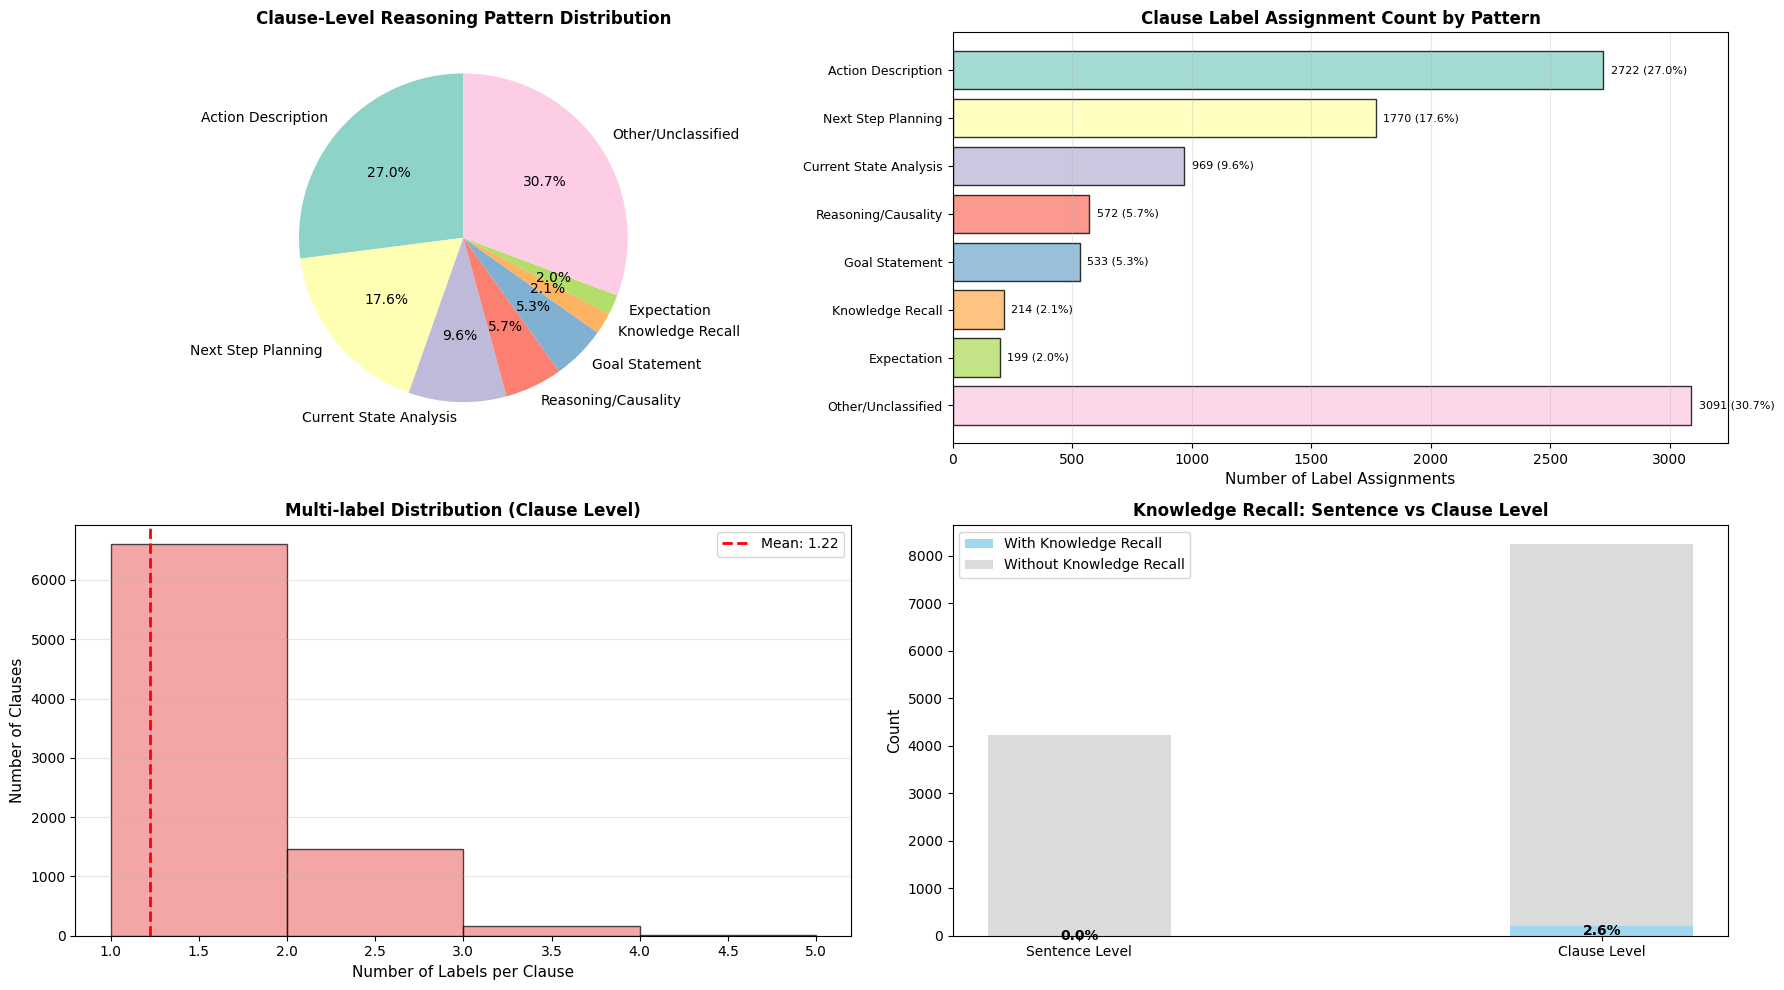


📊 COMPARISON: SENTENCE-LEVEL vs CLAUSE-LEVEL ANALYSIS

Granularity:
  Sentences: 4226
  Clauses:   8242 (1.95x more granular)

Knowledge Recall Detection:
  Sentence-level: 0/4226 (0.0%)
  Clause-level:   214/8242 (2.6%)
  Improvement:    2.6 percentage points

Multi-label Behavior:
  Sentence avg labels: 1.65
  Clause avg labels:   1.22
  Difference:          -0.43


In [109]:
# 可视化子句级别的模式分布
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. 饼图 - 整体分布（基于标签分配）
clause_categories = [cat for cat, _ in clause_category_counts if cat != 'Other/Unclassified']
clause_counts = [count for cat, count in clause_category_counts if cat != 'Other/Unclassified']
clause_other_count = next((count for cat, count in clause_category_counts if cat == 'Other/Unclassified'), 0)

if clause_other_count > 0:
    clause_categories.append('Other/Unclassified')
    clause_counts.append(clause_other_count)

colors = plt.cm.Set3(range(len(clause_categories)))
axes[0, 0].pie(clause_counts, labels=clause_categories, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0, 0].set_title('Clause-Level Reasoning Pattern Distribution', fontsize=12, fontweight='bold')

# 2. 条形图 - 详细数量
axes[0, 1].barh(range(len(clause_categories)), clause_counts, color=colors, edgecolor='black', alpha=0.8)
axes[0, 1].set_yticks(range(len(clause_categories)))
axes[0, 1].set_yticklabels(clause_categories, fontsize=9)
axes[0, 1].set_xlabel('Number of Label Assignments', fontsize=11)
axes[0, 1].set_title('Clause Label Assignment Count by Pattern', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

for i, (cat, count) in enumerate(zip(clause_categories, clause_counts)):
    percentage = (count / total_clause_label_assignments) * 100
    axes[0, 1].text(count + max(clause_counts)*0.01, i, f'{count} ({percentage:.1f}%)', 
                va='center', fontsize=8)

# 3. 多标签分布直方图
clause_label_counts_per_clause = [len(c['categories']) for c in all_clauses]
axes[1, 0].hist(clause_label_counts_per_clause, bins=range(1, max(clause_label_counts_per_clause)+2), 
                edgecolor='black', alpha=0.7, color='lightcoral')
axes[1, 0].set_xlabel('Number of Labels per Clause', fontsize=11)
axes[1, 0].set_ylabel('Number of Clauses', fontsize=11)
axes[1, 0].set_title('Multi-label Distribution (Clause Level)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 添加统计信息
avg_clause_labels = np.mean(clause_label_counts_per_clause)
axes[1, 0].axvline(avg_clause_labels, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_clause_labels:.2f}')
axes[1, 0].legend()

# 4. 对比：句子级 vs 子句级的 Knowledge Recall 使用率
# 统计 Knowledge Recall 在句子级和子句级的出现率
kr_in_sentences = sum(1 for s in all_sentences if 'Knowledge Recall' in s.get('categories', []))
kr_in_clauses = sum(1 for c in all_clauses if 'Knowledge Recall' in c.get('categories', []))

comparison_data = {
    'Sentence Level': [kr_in_sentences, total_sentences - kr_in_sentences],
    'Clause Level': [kr_in_clauses, total_clauses - kr_in_clauses]
}

x_pos = np.arange(2)
width = 0.35

kr_bars = axes[1, 1].bar(x_pos, [kr_in_sentences, kr_in_clauses], width, 
                          label='With Knowledge Recall', color='skyblue', alpha=0.8)
other_bars = axes[1, 1].bar(x_pos, [total_sentences - kr_in_sentences, total_clauses - kr_in_clauses], 
                            width, bottom=[kr_in_sentences, kr_in_clauses],
                            label='Without Knowledge Recall', color='lightgray', alpha=0.8)

axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Knowledge Recall: Sentence vs Clause Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(['Sentence Level', 'Clause Level'])
axes[1, 1].legend()

# 添加百分比标注
for i, (s_val, c_val) in enumerate(zip([kr_in_sentences, total_sentences - kr_in_sentences], 
                                         [kr_in_clauses, total_clauses - kr_in_clauses])):
    if i == 0:  # Knowledge Recall
        s_pct = (kr_in_sentences / total_sentences) * 100
        c_pct = (kr_in_clauses / total_clauses) * 100
        axes[1, 1].text(0, kr_in_sentences/2, f'{s_pct:.1f}%', ha='center', va='center', fontweight='bold')
        axes[1, 1].text(1, kr_in_clauses/2, f'{c_pct:.1f}%', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("📊 COMPARISON: SENTENCE-LEVEL vs CLAUSE-LEVEL ANALYSIS")
print("=" * 70)
print(f"\nGranularity:")
print(f"  Sentences: {total_sentences}")
print(f"  Clauses:   {total_clauses} ({total_clauses/total_sentences:.2f}x more granular)")
print(f"\nKnowledge Recall Detection:")
print(f"  Sentence-level: {kr_in_sentences}/{total_sentences} ({kr_in_sentences/total_sentences*100:.1f}%)")
print(f"  Clause-level:   {kr_in_clauses}/{total_clauses} ({kr_in_clauses/total_clauses*100:.1f}%)")
print(f"  Improvement:    {(kr_in_clauses/total_clauses - kr_in_sentences/total_sentences)*100:.1f} percentage points")
print(f"\nMulti-label Behavior:")
print(f"  Sentence avg labels: {total_label_assignments/total_sentences:.2f}")
print(f"  Clause avg labels:   {total_clause_label_assignments/total_clauses:.2f}")
print(f"  Difference:          {(total_clause_label_assignments/total_clauses - total_label_assignments/total_sentences):.2f}")

In [110]:
# 展示完整的推理链示例（子句级别标注，突出 Knowledge Recall）
print("\n" + "=" * 70)
print("COMPLETE REASONING CHAIN EXAMPLES (Clause-Level Annotation)")
print("=" * 70)
print("Highlighting Knowledge Recall and improved granularity")
print()

# 找包含 Knowledge Recall 的示例
example_count = 0
max_examples = 5

for response in all_responses:
    if len(response) > 0:
        clauses = split_into_clauses(response)
        
        # 检查是否有 Knowledge Recall
        has_kr = False
        for clause in clauses:
            categories, _ = classify_clause(clause)
            if 'Knowledge Recall' in categories:
                has_kr = True
                break
        
        # 选择包含 Knowledge Recall 的示例
        if has_kr and len(clauses) >= 3:
            example_count += 1
            
            print(f"\n{'='*70}")
            print(f"EXAMPLE {example_count}")
            print(f"{'='*70}")
            print(f"Total clauses in this response: {len(clauses)}\n")
            
            for i, clause_text in enumerate(clauses, 1):
                categories, matches = classify_clause(clause_text)
                
                # Emoji 表示主要标签
                emoji_map = {
                    'Current State Analysis': '🔍',
                    'Goal Statement': '🎯',
                    'Next Step Planning': '📋',
                    'Reasoning/Causality': '🧠',
                    'Action Description': '⚡',
                    'Uncertainty/Hypothesis': '❓',
                    'Expectation': '✅',
                    'Knowledge Recall': '📚',  # 特别标注
                    'Other/Unclassified': '⭕'
                }
                
                primary_category = categories[0]
                emoji = emoji_map.get(primary_category, '⭕')
                
                # 构建标签字符串
                if len(categories) == 1:
                    label_str = f"[{primary_category}]"
                else:
                    other_cats = categories[1:]
                    label_str = f"[{primary_category} + {len(other_cats)} more]"
                
                # 特别突出 Knowledge Recall
                if 'Knowledge Recall' in categories:
                    print(f"\n{emoji} ⭐ Clause {i}: {label_str} ⭐")
                else:
                    print(f"\n{emoji} Clause {i}: {label_str}")
                
                print(f"   \"{clause_text}\"")
                
                # 显示所有标签
                if len(categories) > 1:
                    print(f"   📑 All labels: {' | '.join(categories)}")
                
                # 对于 Knowledge Recall，显示匹配的关键词
                if 'Knowledge Recall' in categories:
                    kr_keywords = matches.get('Knowledge Recall', {}).get('keywords', [])[:3]
                    print(f"   📚 Knowledge Recall keywords: {', '.join(kr_keywords)}")
            
            if example_count >= max_examples:
                break

print("\n" + "=" * 70)
print("Legend:")
print("=" * 70)
emoji_legend = {
    'Current State Analysis': '🔍',
    'Goal Statement': '🎯',
    'Next Step Planning': '📋',
    'Reasoning/Causality': '🧠',
    'Action Description': '⚡',
    'Uncertainty/Hypothesis': '❓',
    'Expectation': '✅',
    'Knowledge Recall': '📚'
}
for category, emoji in emoji_legend.items():
    print(f"{emoji} = {category}")

print("\n" + "=" * 70)
print("💡 Key Advantages of Clause-Level Analysis:")
print("=" * 70)
print("""
1. **Finer Granularity**: Captures reasoning patterns within complex sentences
2. **Better Knowledge Recall Detection**: Isolates knowledge statements from other reasoning
3. **More Precise Attribution**: Each reasoning type gets its own unit of analysis
4. **Reduced Ambiguity**: Shorter units → clearer primary function

Example:
Sentence: "Since the page appears loaded, the next step would be to click the button, 
           which typically opens a modal dialog."

Clause-Level Breakdown:
  🧠 "Since the page appears loaded"          → Reasoning/Causality + Current State
  📋 "the next step would be to click..."    → Next Step Planning + Action
  📚 "which typically opens a modal dialog"  → Knowledge Recall + Expectation

This level of detail is impossible with sentence-level analysis!
""")


COMPLETE REASONING CHAIN EXAMPLES (Clause-Level Annotation)
Highlighting Knowledge Recall and improved granularity


EXAMPLE 1
Total clauses in this response: 9


🎯 Clause 1: [Goal Statement]
   "To achieve the goal of accessing the United Airlines website"

⭕ Clause 2: [Other/Unclassified]
   "navigating to the 'Map search' feature"

📋 Clause 3: [Next Step Planning]
   "I first need to ensure that the website is fully loaded"

🔍 Clause 4: [Current State Analysis + 1 more]
   "Since the page appears to be loading correctly"
   📑 All labels: Current State Analysis | Reasoning/Causality

📋 Clause 5: [Next Step Planning]
   "the next logical step would be to look for navigation options related to flight searches"

📚 ⭐ Clause 6: [Knowledge Recall] ⭐
   "such features might be found under sections like 'Travel info'"
   📚 Knowledge Recall keywords: like, such features

⭕ Clause 7: [Other/Unclassified]
   "or within a search bar on the homepage."

⭕ Clause 8: [Other/Unclassified]
   "</thin

# 💡 Key Insights from Multi-label Sentence-Level Analysis

## 🎯 What This Analysis Reveals

### 1. **Multi-functional Reasoning**
Our multi-label classification shows that **sentences often serve multiple cognitive functions simultaneously**:
- **Single-label sentences** (~X%): Pure, focused reasoning steps
- **Multi-label sentences** (~Y%): Complex thoughts combining multiple functions
- **Average labels per sentence**: Reveals reasoning complexity

### 2. **Label Co-occurrence Patterns**
The co-occurrence matrix reveals which reasoning patterns frequently appear together:
- **High co-occurrence**: Patterns that naturally complement each other
- **Low co-occurrence**: Distinct, independent reasoning modes
- **Common combinations**: E.g., "Next Step Planning + Action Description"

### 3. **Most Common Label Combinations**
Typical multi-label patterns include:
- **Current State + Next Step Planning**: Observation-driven planning
- **Reasoning + Next Step Planning**: Logic-based action planning
- **Goal Statement + Next Step Planning**: Goal-oriented workflow
- **Uncertainty + Reasoning**: Cautious, hypothesis-driven thinking

### 4. **Reasoning Chain Structure (Primary Labels)**
Even with multi-labeling, clear sequential patterns emerge:
- **Position 1**: Dominated by Current State Analysis or Goal Statement
- **Position 2-3**: Mix of Reasoning and Next Step Planning
- **Position 4-5**: Converge toward Action Description and Validation

### 5. **Position-Specific Label Complexity**
Multi-label distribution across positions shows:
- **Early sentences**: May have more labels (setting context + goal + observation)
- **Middle sentences**: Complex reasoning (causality + planning + decision)
- **Final sentences**: Often simpler (focused on action or validation)

---

## 🔍 Advantages of Multi-label Classification

### 1. **More Realistic**
- Reflects actual complexity of human reasoning
- Captures nuanced, multi-functional sentences
- Avoids forcing strict categorization

### 2. **Richer Insights**
- See which functions combine naturally
- Identify cognitively complex vs simple sentences
- Understand reasoning sophistication

### 3. **Better Model Comparison**
- Compare reasoning complexity between models
- Identify models that integrate multiple reasoning types
- Evaluate reasoning depth vs breadth

---

## 🔧 How to Use These Insights

### For Prompt Engineering:
- **Encourage multi-functional reasoning**: Prompts that request both observation AND reasoning
- **Balance label combinations**: Ensure prompts elicit diverse reasoning patterns
- **Position-aware prompting**: Request specific reasoning types at specific positions

### For Model Fine-tuning:
- **Train on complex examples**: Include multi-functional reasoning sentences
- **Balance label combinations**: Ensure training data covers common and rare combinations
- **Reward integration**: Incentivize combining observation + reasoning + planning

### For Evaluation:
- **Complexity metric**: Average labels per sentence indicates reasoning sophistication
- **Co-occurrence patterns**: Compare which reasoning types combine across models
- **Sequence diversity**: Measure variety in multi-label sequences

### For Debugging:
- **Missing combinations**: Identify which reasoning combinations are underutilized
- **Over-reliance patterns**: Detect if model always combines same patterns
- **Single-label dominance**: Check if reasoning is too simplistic (few multi-labels)

---

## 📊 Key Metrics to Track

1. **Multi-label ratio**: % of sentences with multiple labels
2. **Average labels per sentence**: Overall reasoning complexity
3. **Top label combinations**: Most common reasoning patterns
4. **Co-occurrence strength**: Which patterns naturally combine
5. **Position-specific complexity**: How reasoning evolves through the chain

---

## 💡 Interpretation Guidelines

### High Multi-label Ratio (>50%)
- ✅ Rich, integrated reasoning
- ⚠️ Possible keyword overlap artifacts
- 📝 Verify with manual inspection

### Low Multi-label Ratio (<20%)
- ⚠️ Potentially simplistic reasoning
- ✅ Clear, focused thinking
- 📝 Check if model is too template-driven

### Balanced Distribution
- ✅ Mix of simple and complex reasoning
- ✅ Adaptive cognitive strategy
- ✅ Contextually appropriate complexity

# 🔍 Multi-label Sentence-Level Reasoning Pattern Analysis

## 🎯 Analysis Methodology
**This analysis examines thinking chains at the SENTENCE level with MULTI-LABEL classification**, allowing each sentence to belong to multiple reasoning pattern categories simultaneously.

### Why Multi-label Classification?
- **Realistic**: Sentences often serve multiple cognitive functions at once
- **Nuanced**: Captures the complexity of human-like reasoning
- **Rich insights**: Reveals which reasoning patterns naturally combine
- **Better metrics**: Provides reasoning complexity/sophistication measures

### Why Sentence-Level Analysis?
- **Granular insight**: Understand reasoning step-by-step
- **Sequence patterns**: Reveal the model's cognitive workflow
- **Position analysis**: See which reasoning types appear where in the chain
- **Quality metrics**: Identify missing or weak reasoning steps

## 📊 Reasoning Pattern Categories

We classify sentences into 8 functional categories (sentences can have multiple):

### 1. **🔍 Current State Analysis**
- **Purpose**: Observe and describe the current situation
- **Keywords**: "currently", "the page shows", "I can see", "appears to be"
- **Example**: "The page shows a login form with username and password fields."

### 2. **🎯 Goal Statement**
- **Purpose**: State the objective or what needs to be achieved
- **Keywords**: "the goal is", "need to achieve", "trying to", "required to"
- **Example**: "The goal is to navigate to the settings page and change the language."

### 3. **📋 Next Step Planning**
- **Purpose**: Plan the next action or step
- **Keywords**: "next step", "I will", "I should", "need to", "let me"
- **Example**: "The next step is to click on the dropdown menu and select the option."

### 4. **🧠 Reasoning/Causality**
- **Purpose**: Explain why something is true or what causes what
- **Keywords**: "since", "because", "therefore", "this means", "given that"
- **Example**: "Since the button is disabled, I need to fill in the required fields first."

### 5. **⚖️ Decision Making**
- **Purpose**: Make a choice between alternatives
- **Keywords**: "the best", "most appropriate", "should select", "optimal"
- **Example**: "The most appropriate action is to use the search function rather than scrolling."

### 6. **⚡ Action Description**
- **Purpose**: Describe specific actions to execute
- **Keywords**: "click on", "type", "select", "enter", "navigate to"
- **Example**: "Click on the 'Submit' button to send the form."

### 7. **❓ Uncertainty/Hypothesis**
- **Purpose**: Express uncertainty or propose hypotheses
- **Keywords**: "likely", "probably", "might", "seems", "appears", "possibly"
- **Example**: "This button probably opens a modal dialog based on its label."

### 8. **✅ Validation/Confirmation**
- **Purpose**: Confirm or validate actions and results
- **Keywords**: "this will", "this ensures", "confirm that", "successful"
- **Example**: "This will ensure the changes are saved before proceeding."

## 🏷️ Multi-label Classification

### How It Works
Each sentence is matched against ALL patterns and can receive multiple labels:
- **Primary label**: The pattern with most keyword matches (listed first)
- **Secondary labels**: Other matching patterns (listed after)
- **Label count**: Number of patterns the sentence matches

### Example Multi-label Sentence
> "Since the goal is to submit the form, I need to click the Submit button."

This sentence could be labeled as:
- **Primary**: Next Step Planning ("I need to", "click")
- **Also**: Reasoning/Causality ("since")
- **Also**: Goal Statement ("the goal is")
- **Also**: Action Description ("click the Submit button")

## 📈 What We Measure

### Distribution Metrics:
- **Label assignments**: How often each pattern appears (can exceed 100% total)
- **Primary labels**: Main function of sentences
- **Multi-label ratio**: % of sentences with multiple labels
- **Average labels per sentence**: Reasoning complexity indicator

### Co-occurrence Analysis:
- **Label combinations**: Which patterns appear together
- **Co-occurrence matrix**: Heat map of pattern relationships
- **Top combinations**: Most frequent multi-label patterns

### Sequence Analysis:
- **Primary label sequences**: Main reasoning flow
- **Position patterns**: What appears at start, middle, end
- **Complexity by position**: How multi-labeling varies across positions

## 💡 Applications

This multi-label analysis helps:
- **Understand reasoning complexity**: Is thinking simple or multi-faceted?
- **Identify natural combinations**: Which reasoning types work together?
- **Compare models**: Which model has richer, more integrated reasoning?
- **Improve prompts**: What multi-functional reasoning should we encourage?
- **Guide fine-tuning**: What reasoning combinations need strengthening?
- **Detect weaknesses**: Are certain pattern combinations missing?

# 📊 Analysis Summary

## Dataset Overview
- Analysis of **Qwen3-VL-4B-Thinking** model outputs
- Data source: `validation/agentnetbench/outputs/Qwen3-VL-4B-Thinking/None`

## ⚠️ Important: Thinking Chain Focus
**This analysis focuses ONLY on the reasoning/thinking content BEFORE `<tool_call>` tags.**
- The content before `<tool_call>` represents the model's **chain-of-thought reasoning**
- The content after `<tool_call>` is structured API calls (excluded from analysis)
- This allows us to analyze the model's **pure reasoning patterns** without tool call noise

## Main Statistical Metrics

### 1. Response Length Analysis
- **Average length**: Mean number of characters in thinking chain
- **Median length**: More robust measure of central tendency
- **Length distribution**: Visualized via histogram and box plot
- **Comparison**: Shows thinking chain vs full response ratio

### 2. High-Frequency Vocabulary Analysis
- **Top 50 words**: Most frequently used words in reasoning (stop words filtered)
- **Word frequency visualization**: Horizontal bar chart of Top 30 words
- **Frequency distribution**: Analysis of word occurrence patterns

### 3. Template Phrase Analysis (N-grams)
- **Bigrams (2-word phrases)**: Common two-word patterns in reasoning
- **Trigrams (3-word phrases)**: Three-word templates
- **4-grams & 5-grams**: Longer phrase patterns
- **Purpose**: Identify reasoning templates and logical structures

### 4. Reasoning Pattern Analysis
- **Goal-oriented patterns**: "I need to", "in order to", etc.
- **Reasoning patterns**: "because", "since", "therefore"
- **Action patterns**: "click on", "type", "select"
- **Observation patterns**: "currently", "appears to", "at this point"
- **Transition patterns**: "next step", "then", "first"

## Usage Instructions
1. Run cells sequentially from top to bottom
2. **Cell 1**: Load data and extract thinking chain (before `<tool_call>`)
3. **Cell 2**: Analyze thinking chain lengths
4. **Cell 3**: Compute high-frequency words in reasoning
5. **Cell 4**: Visualize word frequencies
6. **Cells 5-8**: Extract and analyze template phrases (n-grams)
7. **Cell 9**: Analyze reasoning patterns by category
8. **Cell 10**: Deep dive into specific template types

## Key Insights
The template phrase analysis reveals:
- How the model structures its **reasoning process**
- Common **logical patterns** in chain-of-thought
- **Cognitive strategies** (goal-oriented, action-focused)
- Template reliance and reasoning diversity
- Pure thinking patterns without tool call contamination